<a href="https://colab.research.google.com/github/kakakeyvan/Persian_Music_Shour/blob/main/Modeling_of_Persian_Music.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ==============================================================================
# BAYESIAN — ADAPTIVE BEAR DISTRIBUTIONAL DIVERGENCE
# ==============================================================================
#
# FINAL DISTRIBUTIONAL ANALYSIS
#
# Compares REAL gusheh pitch distributions against
# ADAPTIVE BEAR generated pitch distributions for all 10 gushehs.
#
# Metrics:
#   1. KL(Real || Generated)
#   2. KL(Generated || Real)
#   3. Symmetric KL
#   4. Jensen-Shannon Divergence
#   5. Total Variation Distance
#   6. Hellinger Distance
#   7. Bhattacharyya Distance
#   8. Cross Entropy
#   9. Perplexity
#  10. Interval Distribution JS divergence (melodic structure)
#
# Outputs:
#   - Main divergence CSV
#   - JS ranking CSV
#   - Pitch distribution CSV
#   - Interval distribution CSV
#   - Mean summary CSV
#   - Plots for each metric
#   - Per-gusheh pitch distribution plots
# ==============================================================================

import os
import ast
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================

RESULT_DIR = "/content/BEAR_DISTRIBUTION_RESULTS"
os.makedirs(RESULT_DIR, exist_ok=True)

ALPHA = 0.5
EPS = 1e-15

N_MELODIES_EXPECTED = 1000
MELODY_LENGTH_EXPECTED = 64


# ==============================================================================
# 2. GUSHEHS
# ==============================================================================

GUSHEHS = {
    "Daramad":            "01 - Daramad (1).csv",
    "Panjeh-Shahri":      "02 - Panjehsheri.csv",
    "Kereshmeh":          "03 - Kereshmeh.csv",
    "Rahab":              "04 - Rahab.csv",
    "Ouj":                "05 - Ouj.csv",
    "Molla-Nazi":         "06 - Molla Nazi.csv",
    "Naghmehye-Avval":    "07 - Naghmehye avval.csv",
    "Naghmehye-Dovvom":   "08 - Naghmehye Dovvom.csv",
    "Zirkeshe-Salmak":    "09 - Zirkeshe Salmak.csv",
    "Salmak":             "10 - Salmak.csv",
}

PITCH_COLUMN = "Pitch / microtone style"


# ==============================================================================
# 3. HEADER
# ==============================================================================

print("=" * 78)
print("BAYESIAN — ADAPTIVE BEAR DISTRIBUTIONAL DIVERGENCE")
print("=" * 78)
print("\nCompares REAL gusheh distributions against")
print("ADAPTIVE BEAR generated distributions.")
print("\nOnly ADAPTIVE_BEAR_* generated files are accepted.")


# ==============================================================================
# 4. PITCH PARSER
# ==============================================================================

def parse_pitch_value(value):
    if pd.isna(value):
        return []

    value = str(value).strip()

    if not value:
        return []

    if value.startswith("[") and value.endswith("]"):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                result = []
                for item in parsed:
                    item = str(item).strip()
                    if item in ["", "[", "]"]:
                        continue
                    result.append(item)
                return result
        except Exception:
            pass

    value = value.replace("[", "").replace("]", "").strip()

    if not value:
        return []

    return [value]


# ==============================================================================
# 5. FIND ORIGINAL FILE
# ==============================================================================

ORIGINAL_SEARCH_DIRS = [
    "/content",
    "/content/data",
    "/content/DATA",
    "/content/SHOURCORPUS",
    "/content/ShourCorpus",
    "/content/SHOUR",
]


def find_original_file(filename):
    for directory in ORIGINAL_SEARCH_DIRS:
        if not os.path.exists(directory):
            continue
        path = os.path.join(directory, filename)
        if os.path.isfile(path):
            return path

    for directory in ORIGINAL_SEARCH_DIRS:
        if not os.path.exists(directory):
            continue
        matches = glob.glob(
            os.path.join(directory, "**", filename),
            recursive=True
        )
        if matches:
            return matches[0]

    return None


# ==============================================================================
# 6. LOAD REAL GUSHEHS
# ==============================================================================

print("\n" + "=" * 78)
print("LOADING ORIGINAL GUSHEHS")
print("=" * 78)

REAL_DATA = {}

for gusheh, filename in GUSHEHS.items():
    path = find_original_file(filename)

    if path is None:
        raise FileNotFoundError(f"Original file not found: {filename}")

    df = pd.read_csv(path)

    if PITCH_COLUMN not in df.columns:
        raise ValueError(
            f"Pitch column not found in {path}\n"
            f"Available: {list(df.columns)}"
        )

    sequence = []
    for value in df[PITCH_COLUMN]:
        sequence.extend(parse_pitch_value(value))

    if not sequence:
        raise ValueError(f"No pitches found for {gusheh}")

    REAL_DATA[gusheh] = sequence

    states = sorted(set(sequence))
    print(
        f"{gusheh:20s} | "
        f"N = {len(sequence):4d} | "
        f"States = {states}"
    )


# ==============================================================================
# 7. GLOBAL VOCABULARY
# ==============================================================================

GLOBAL_STATES = sorted(
    set(p for seq in REAL_DATA.values() for p in seq)
)

print("\nGlobal real pitch vocabulary:")
print(GLOBAL_STATES)


# ==============================================================================
# 8. FUZZY FILE FINDING FOR GENERATED FILES
# ==============================================================================

def normalize_name(text):
    text = str(text).lower()
    text = text.replace("_", "")
    text = text.replace("-", "")
    text = text.replace(" ", "")
    return text


def find_generated_file(gusheh):
    candidates = [
        f"ADAPTIVE_BEAR_{gusheh}_generated_melodies.csv",
        f"ADAPTIVE_BEAR_{gusheh}_generated.csv",
        f"{gusheh}_ADAPTIVE_BEAR_generated_melodies.csv",
        f"{gusheh}_adaptive_bear_generated_melodies.csv",
        f"{gusheh}_generated_melodies.csv",
        f"{gusheh}_generated.csv",
        f"adaptive_bear_{gusheh}_generated_melodies.csv",
        f"adaptive_bear_{gusheh}_generated.csv",
    ]

    for filename in candidates:
        path = os.path.join(RESULT_DIR, filename)
        if os.path.isfile(path):
            return path

    all_csv = glob.glob(os.path.join(RESULT_DIR, "*.csv"))
    gusheh_norm = normalize_name(gusheh)

    # Priority 1: adaptive bear + gusheh + generated
    for path in all_csv:
        base = normalize_name(os.path.basename(path))
        if (
            "adaptivebear" in base
            and gusheh_norm in base
            and ("generated" in base or "melod" in base)
        ):
            return path

    # Priority 2: gusheh + generated
    for path in all_csv:
        base = normalize_name(os.path.basename(path))
        if (
            gusheh_norm in base
            and "generated" in base
            and "melod" in base
        ):
            return path

    return None


# ==============================================================================
# 9. STRICT FILE VALIDATION
# ==============================================================================

print("\n" + "=" * 78)
print("SEARCHING FOR ADAPTIVE BEAR GENERATED FILES")
print("=" * 78)

GENERATED_PATHS = {}
missing = []

for gusheh in GUSHEHS:
    path = find_generated_file(gusheh)

    if path is None:
        print(f"{gusheh:20s} | NOT FOUND")
        missing.append(gusheh)
    else:
        print(f"{gusheh:20s} | {os.path.basename(path)}")
        GENERATED_PATHS[gusheh] = path

if missing:
    print("\n" + "=" * 78)
    print("ERROR — ADAPTIVE BEAR FILES MISSING")
    print("=" * 78)
    for gusheh in missing:
        print(f"  - {gusheh}")
    raise RuntimeError(
        "\nSTOPPED SAFELY.\n"
        "Generate all 10 Adaptive Bear melody files first."
    )


# ==============================================================================
# 10. ROBUST GENERATED PITCH EXTRACTION
# ==============================================================================

def extract_generated_pitches(df, valid_states):
    """
    Extract pitch tokens from generated CSV.

    Tries structured extraction (note_1...note_64) first,
    then falls back to cell-by-cell token matching.
    """
    valid_states = set(valid_states)
    generated = []

    # Structured extraction: note_1 ... note_64
    note_columns = [
        c for c in df.columns
        if isinstance(c, str) and c.startswith("note_")
    ]

    if note_columns:
        for col in note_columns:
            for value in df[col]:
                parsed = parse_pitch_value(value)
                for token in parsed:
                    token = str(token).strip()
                    if token in valid_states:
                        generated.append(token)
        return generated

    # Fallback: scan every cell
    for col in df.columns:
        for value in df[col]:
            parsed = parse_pitch_value(value)
            for token in parsed:
                token = str(token).strip()
                if token in valid_states:
                    generated.append(token)

    return generated


def load_generated_melodies(path, gusheh):
    df = pd.read_csv(path)

    if len(df) != N_MELODIES_EXPECTED:
        raise ValueError(
            f"{gusheh}: Expected {N_MELODIES_EXPECTED} melodies, "
            f"found {len(df)}."
        )

    return df


# ==============================================================================
# 11. LOAD ALL GENERATED DATA
# ==============================================================================

print("\n" + "=" * 78)
print("LOADING ADAPTIVE BEAR GENERATED MELODIES")
print("=" * 78)

GENERATED_DATA = {}
GENERATED_DFS = {}

for gusheh in GUSHEHS:
    df = load_generated_melodies(GENERATED_PATHS[gusheh], gusheh)

    valid_states = set(REAL_DATA[gusheh])

    pitches = extract_generated_pitches(df, valid_states)

    if len(pitches) == 0:
        raise ValueError(f"{gusheh}: No valid pitches found.")

    GENERATED_DATA[gusheh] = pitches
    GENERATED_DFS[gusheh] = df

    print(
        f"{gusheh:20s} | "
        f"Melodies = {len(df):4d} | "
        f"Pitches = {len(pitches):6d} | "
        f"Shape = {df.shape}"
    )


# ==============================================================================
# 12. PROBABILITY DISTRIBUTIONS
# ==============================================================================

def smoothed_distribution(sequence, states, alpha=ALPHA):
    counts = {state: 0.0 for state in states}

    for pitch in sequence:
        if pitch in counts:
            counts[pitch] += 1.0

    values = np.array(
        [counts[state] + alpha for state in states],
        dtype=float
    )
    values /= values.sum()
    return values


def interval_distribution(sequence, states):
    """
    Distribution of absolute pitch intervals (in state-index steps).
    Captures melodic contour information beyond marginal pitch frequency.
    """
    state_to_idx = {s: i for i, s in enumerate(states)}

    intervals = []
    for i in range(len(sequence) - 1):
        if sequence[i] in state_to_idx and sequence[i + 1] in state_to_idx:
            idx1 = state_to_idx[sequence[i]]
            idx2 = state_to_idx[sequence[i + 1]]
            intervals.append(abs(idx2 - idx1))

    if not intervals:
        return {}

    counts = Counter(intervals)
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}


# ==============================================================================
# 13. DIVERGENCE FUNCTIONS
# ==============================================================================

def kl_divergence(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p = np.clip(p, EPS, None)
    q = np.clip(q, EPS, None)

    p /= p.sum()
    q /= q.sum()

    return float(np.sum(p * np.log(p / q)))


def jensen_shannon(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p = np.clip(p, EPS, None)
    q = np.clip(q, EPS, None)

    p /= p.sum()
    q /= q.sum()

    m = 0.5 * (p + q)

    return 0.5 * kl_divergence(p, m) + 0.5 * kl_divergence(q, m)


def total_variation(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p /= p.sum()
    q /= q.sum()

    return float(0.5 * np.sum(np.abs(p - q)))


def hellinger_distance(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p /= p.sum()
    q /= q.sum()

    return float(
        np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))
    )


def bhattacharyya_distance(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p /= p.sum()
    q /= q.sum()

    coefficient = np.sum(np.sqrt(p * q))
    coefficient = np.clip(coefficient, EPS, 1.0)

    return float(-np.log(coefficient))


def cross_entropy(p_real, q_generated):
    p = np.asarray(p_real, dtype=float)
    q = np.asarray(q_generated, dtype=float)

    p /= p.sum()
    q /= q.sum()

    q = np.clip(q, EPS, None)

    return float(-np.sum(p * np.log(q)))


def perplexity_from_cross_entropy(ce):
    return float(np.exp(ce))


# ==============================================================================
# 14. COMPUTE ALL METRICS
# ==============================================================================

print("\n" + "=" * 78)
print("COMPUTING DIVERGENCES")
print("=" * 78)

results = []
distribution_rows = []
interval_rows = []

for gusheh in GUSHEHS:
    real_sequence = REAL_DATA[gusheh]
    generated_sequence = GENERATED_DATA[gusheh]

    # Local union vocabulary
    local_states = sorted(
        set(real_sequence) | set(generated_sequence)
    )

    p_real = smoothed_distribution(real_sequence, local_states, ALPHA)
    p_generated = smoothed_distribution(generated_sequence, local_states, ALPHA)

    # Pitch-level divergences
    kl_rg = kl_divergence(p_real, p_generated)
    kl_gr = kl_divergence(p_generated, p_real)
    sym_kl = 0.5 * (kl_rg + kl_gr)
    js = jensen_shannon(p_real, p_generated)
    tv = total_variation(p_real, p_generated)
    hell = hellinger_distance(p_real, p_generated)
    bhat = bhattacharyya_distance(p_real, p_generated)
    ce = cross_entropy(p_real, p_generated)
    ppl = perplexity_from_cross_entropy(ce)

    # Interval distribution
    real_intervals = interval_distribution(real_sequence, local_states)
    gen_intervals = interval_distribution(generated_sequence, local_states)

    all_intervals = sorted(set(real_intervals) | set(gen_intervals))

    if all_intervals:
        p_real_int = np.array(
            [real_intervals.get(k, 0) for k in all_intervals],
            dtype=float
        )
        p_gen_int = np.array(
            [gen_intervals.get(k, 0) for k in all_intervals],
            dtype=float
        )

        p_real_int = np.clip(p_real_int, EPS, None)
        p_gen_int = np.clip(p_gen_int, EPS, None)
        p_real_int /= p_real_int.sum()
        p_gen_int /= p_gen_int.sum()

        js_intervals = jensen_shannon(p_real_int, p_gen_int)
    else:
        js_intervals = np.nan

    results.append({
        "Gusheh": gusheh,
        "Real_N": len(real_sequence),
        "Generated_N": len(generated_sequence),
        "Number_of_States": len(local_states),
        "KL_Real_to_Generated": kl_rg,
        "KL_Generated_to_Real": kl_gr,
        "Symmetric_KL": sym_kl,
        "Jensen_Shannon": js,
        "Total_Variation": tv,
        "Hellinger": hell,
        "Bhattacharyya": bhat,
        "Cross_Entropy": ce,
        "Perplexity": ppl,
        "JS_Intervals": js_intervals,
    })

    for i, state in enumerate(local_states):
        distribution_rows.append({
            "Gusheh": gusheh,
            "Pitch": state,
            "Real_Probability": p_real[i],
            "Adaptive_Bear_Probability": p_generated[i],
            "Absolute_Difference": abs(p_real[i] - p_generated[i]),
        })

    for k in all_intervals:
        interval_rows.append({
            "Gusheh": gusheh,
            "Interval": k,
            "Real_Probability": real_intervals.get(k, 0.0),
            "Adaptive_Bear_Probability": gen_intervals.get(k, 0.0),
        })

    print(f"\n{gusheh}")
    print(f"  Real N          : {len(real_sequence)}")
    print(f"  Generated N     : {len(generated_sequence)}")
    print(f"  States          : {len(local_states)}")
    print(f"  KL R||G         : {kl_rg:.6f}")
    print(f"  KL G||R         : {kl_gr:.6f}")
    print(f"  Symmetric KL    : {sym_kl:.6f}")
    print(f"  Jensen-Shannon  : {js:.6f}")
    print(f"  Total Variation : {tv:.6f}")
    print(f"  Hellinger       : {hell:.6f}")
    print(f"  Bhattacharyya   : {bhat:.6f}")
    print(f"  Cross Entropy   : {ce:.6f}")
    print(f"  Perplexity      : {ppl:.6f}")
    print(f"  JS Intervals    : {js_intervals:.6f}")


# ==============================================================================
# 15. DATAFRAMES
# ==============================================================================

results_df = pd.DataFrame(results)
distribution_df = pd.DataFrame(distribution_rows)
interval_df = pd.DataFrame(interval_rows)

ranking_df = results_df.sort_values(
    "Jensen_Shannon", ascending=True
).reset_index(drop=True)

ranking_df.insert(
    0,
    "JS_Rank",
    np.arange(1, len(ranking_df) + 1)
)


# ==============================================================================
# 16. SAVE CSV
# ==============================================================================

main_csv = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_DISTRIBUTIONAL_DIVERGENCE.csv"
)
ranking_csv = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_JS_RANKING.csv"
)
distribution_csv = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_PITCH_DISTRIBUTIONS.csv"
)
interval_csv = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_INTERVAL_DISTRIBUTIONS.csv"
)

results_df.to_csv(main_csv, index=False)
ranking_df.to_csv(ranking_csv, index=False)
distribution_df.to_csv(distribution_csv, index=False)
interval_df.to_csv(interval_csv, index=False)


# ==============================================================================
# 17. PRINT TABLES
# ==============================================================================

print("\n" + "=" * 78)
print("FINAL DIVERGENCE RESULTS")
print("=" * 78)

display_cols = [
    "Gusheh",
    "KL_Real_to_Generated",
    "KL_Generated_to_Real",
    "Symmetric_KL",
    "Jensen_Shannon",
    "Total_Variation",
    "Hellinger",
    "Bhattacharyya",
    "Cross_Entropy",
    "Perplexity",
    "JS_Intervals",
]

display(results_df[display_cols].round(6))


print("\n" + "=" * 78)
print("JENSEN-SHANNON RANKING")
print("=" * 78)

display(ranking_df[["JS_Rank", "Gusheh", "Jensen_Shannon"]].round(6))


# ==============================================================================
# 18. PLOT FUNCTION
# ==============================================================================

def save_bar_plot(df, metric, title, filename, ylabel=None):
    plot_df = df.sort_values(metric, ascending=True)

    plt.figure(figsize=(12, 6))
    plt.bar(plot_df["Gusheh"], plot_df[metric])
    plt.title(title, fontsize=13)
    plt.ylabel(ylabel if ylabel else metric)
    plt.xlabel("Gusheh")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    path = os.path.join(RESULT_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


# ==============================================================================
# 19. GENERATE ALL PLOTS
# ==============================================================================

plot_specs = [
    ("KL_Real_to_Generated", "Adaptive Bear — KL: Real || Generated",
     "ADAPTIVE_BEAR_KL_REAL_TO_GENERATED.png", "KL Divergence"),
    ("KL_Generated_to_Real", "Adaptive Bear — KL: Generated || Real",
     "ADAPTIVE_BEAR_KL_GENERATED_TO_REAL.png", "KL Divergence"),
    ("Symmetric_KL", "Adaptive Bear — Symmetric KL",
     "ADAPTIVE_BEAR_SYMMETRIC_KL.png", "Symmetric KL"),
    ("Jensen_Shannon", "Adaptive Bear — Jensen-Shannon Divergence",
     "ADAPTIVE_BEAR_JENSEN_SHANNON.png", "Jensen-Shannon Divergence"),
    ("Total_Variation", "Adaptive Bear — Total Variation Distance",
     "ADAPTIVE_BEAR_TOTAL_VARIATION.png", "Total Variation"),
    ("Hellinger", "Adaptive Bear — Hellinger Distance",
     "ADAPTIVE_BEAR_HELLINGER.png", "Hellinger Distance"),
    ("Bhattacharyya", "Adaptive Bear — Bhattacharyya Distance",
     "ADAPTIVE_BEAR_BHATTACHARYYA.png", "Bhattacharyya Distance"),
    ("Cross_Entropy", "Adaptive Bear — Cross Entropy",
     "ADAPTIVE_BEAR_CROSS_ENTROPY.png", "Cross Entropy"),
    ("Perplexity", "Adaptive Bear — Distributional Perplexity",
     "ADAPTIVE_BEAR_DISTRIBUTIONAL_PERPLEXITY.png", "Perplexity"),
    ("JS_Intervals", "Adaptive Bear — Interval Distribution JS",
     "ADAPTIVE_BEAR_JS_INTERVALS.png", "JS Divergence (Intervals)"),
]

for metric, title, filename, ylabel in plot_specs:
    save_bar_plot(results_df, metric, title, filename, ylabel)


# ==============================================================================
# 20. COMBINED STANDARDIZED DIVERGENCE PLOT
# ==============================================================================

metric_columns = [
    "KL_Real_to_Generated",
    "KL_Generated_to_Real",
    "Symmetric_KL",
    "Jensen_Shannon",
    "Total_Variation",
    "Hellinger",
    "Bhattacharyya",
]

standardized = results_df[["Gusheh"] + metric_columns].copy()

for metric in metric_columns:
    max_value = standardized[metric].max()
    if max_value > 0:
        standardized[metric] = standardized[metric] / max_value
    else:
        standardized[metric] = 0.0

plt.figure(figsize=(15, 8))
x = np.arange(len(standardized))
width = 0.10

for j, metric in enumerate(metric_columns):
    plt.bar(
        x + (j - len(metric_columns) / 2) * width,
        standardized[metric],
        width=width,
        label=metric,
    )

plt.xticks(x, standardized["Gusheh"], rotation=45, ha="right")
plt.ylabel("Normalized divergence")
plt.title("Adaptive Bear — All Distributional Divergences")
plt.legend(fontsize=8)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

combined_path = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_ALL_DIVERGENCES.png"
)
plt.savefig(combined_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {combined_path}")


# ==============================================================================
# 21. PER-GUSHEH PITCH DISTRIBUTION PLOTS
# ==============================================================================

pitch_plot_dir = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_PITCH_DISTRIBUTIONS"
)
os.makedirs(pitch_plot_dir, exist_ok=True)

for gusheh in GUSHEHS:
    subset = distribution_df[
        distribution_df["Gusheh"] == gusheh
    ].copy()

    subset = subset.sort_values("Real_Probability", ascending=False)

    x = np.arange(len(subset))
    width = 0.38

    plt.figure(figsize=(12, 6))
    plt.bar(x - width / 2, subset["Real_Probability"], width, label="Real")
    plt.bar(
        x + width / 2,
        subset["Adaptive_Bear_Probability"],
        width,
        label="Adaptive Bear",
    )

    plt.xticks(x, subset["Pitch"], rotation=45, ha="right")
    plt.ylabel("Probability")
    plt.xlabel("Pitch")
    plt.title(f"Pitch Distribution — {gusheh}")
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    path = os.path.join(
        pitch_plot_dir,
        f"ADAPTIVE_BEAR_{gusheh}_PITCH_DISTRIBUTION.png",
    )
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()


# ==============================================================================
# 22. BEST / WORST
# ==============================================================================

best_row = ranking_df.iloc[0]
worst_row = ranking_df.iloc[-1]

print("\n" + "=" * 78)
print("FINAL INTERPRETATION")
print("=" * 78)
print(f"\nLowest JS divergence:")
print(f"  {best_row['Gusheh']} -> JS = {best_row['Jensen_Shannon']:.6f}")
print(f"\nHighest JS divergence:")
print(f"  {worst_row['Gusheh']} -> JS = {worst_row['Jensen_Shannon']:.6f}")


# ==============================================================================
# 23. MEAN METRICS
# ==============================================================================

print("\n" + "=" * 78)
print("MEAN DIVERGENCE ACROSS 10 GUSHEHS")
print("=" * 78)

mean_metrics = results_df[
    metric_columns + ["Cross_Entropy", "Perplexity", "JS_Intervals"]
].mean()

for metric, value in mean_metrics.items():
    print(f"{metric:30s}: {value:.6f}")


# ==============================================================================
# 24. SAVE MEAN SUMMARY
# ==============================================================================

mean_summary = pd.DataFrame({
    "Metric": mean_metrics.index,
    "Mean": mean_metrics.values,
})

mean_summary_path = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_DIVERGENCE_MEAN_SUMMARY.csv"
)
mean_summary.to_csv(mean_summary_path, index=False)


# ==============================================================================
# 25. FILE REPORT
# ==============================================================================

print("\n" + "=" * 78)
print("ALL OUTPUT FILES")
print("=" * 78)

print("\nMain divergence table:")
print(main_csv)
print("\nJS ranking:")
print(ranking_csv)
print("\nPitch distributions:")
print(distribution_csv)
print("\nInterval distributions:")
print(interval_csv)
print("\nMean summary:")
print(mean_summary_path)

plot_files = [f for _, _, f, _ in plot_specs] + [
    "ADAPTIVE_BEAR_ALL_DIVERGENCES.png"
]

print("\nPlots:")
for filename in plot_files:
    print(os.path.join(RESULT_DIR, filename))

print("\nPitch distribution plots:")
print(pitch_plot_dir)

print("\n" + "=" * 78)
print("ADAPTIVE BEAR DIVERGENCE ANALYSIS COMPLETE")
print("=" * 78)

BAYESIAN — ADAPTIVE BEAR DISTRIBUTIONAL DIVERGENCE

Compares REAL gusheh distributions against
ADAPTIVE BEAR generated distributions.

Only ADAPTIVE_BEAR_* generated files are accepted.

LOADING ORIGINAL GUSHEHS


FileNotFoundError: Original file not found: 01 - Daramad (1).csv

In [ ]:

import zipfile
import os

ZIP_PATH = "/content/ShourCorpus-main.zip"
EXTRACT_DIR = "/content/ShourCorpus"

# Extract
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)

# Show structure
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

Extracted to: /content/ShourCorpus
ShourCorpus/
  ShourCorpus-main/
    README.md
    Data sheets/
      17 - Do beyti.csv
      16 - Kuchak.csv
      07 - Naghmehye avval.csv
      03 - Kereshmeh.csv
      24 - Moghadamehye Gereyli.csv
      04 - Rahab.csv
      22 - Rahab.csv
      06 - Molla Nazi.csv
      27 - Moghadamehye Qaracheh.csv
      28 - Qaracheh.csv
      29 - Shahnaze kot ya asheqkosh.csv
      18 - Khara.csv
      26 - Shahnaz.csv
      10 - Salmak.csv
      11 - Golriz.csv
      21 - Shour Paein Dasteh.csv
      12 - Majles afruz.csv
      25 - Razavi.csv
      19 - Ghajar.csv
      08 - Naghmehye Dovvom.csv
      23 - Chahar Gusheh.csv
      05 - Ouj.csv
      09 - Zirkeshe Salmak.csv
      20 - Hazin.csv
      13 - Ozzal.csv
      14 - Safa.csv
      01 - Daramad.csv
      02 - Panjehsheri.csv
      15 - Bozorg.csv
    MIDI/
      20 - Hazin.mid
      25 - Razavi.mid
      02 - Panjehsheri.mid
      26 - Shahnaz.mid
      08 - Naghmehye Dovvom.mid
      19 - Ghajar.m

In [ ]:

# ==============================================================================
# BAYESIAN — ADAPTIVE BEAR DISTRIBUTIONAL DIVERGENCE
# ==============================================================================
#
# FINAL DISTRIBUTIONAL ANALYSIS
#
# Compares REAL gusheh pitch distributions against
# ADAPTIVE BEAR generated pitch distributions for all 10 gushehs.
#
# Metrics:
#   1. KL(Real || Generated)
#   2. KL(Generated || Real)
#   3. Symmetric KL
#   4. Jensen-Shannon Divergence
#   5. Total Variation Distance
#   6. Hellinger Distance
#   7. Bhattacharyya Distance
#   8. Cross Entropy
#   9. Perplexity
#  10. Interval Distribution JS divergence (melodic structure)
# ==============================================================================

import os
import ast
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================

RESULT_DIR = "/content/BEAR_DISTRIBUTION_RESULTS"
os.makedirs(RESULT_DIR, exist_ok=True)

ALPHA = 0.5
EPS = 1e-15

N_MELODIES_EXPECTED = 1000
MELODY_LENGTH_EXPECTED = 64


# ==============================================================================
# 2. GUSHEHS
# ==============================================================================

GUSHEHS = {
    "Daramad":            "01 - Daramad.csv",
    "Panjeh-Shahri":      "02 - Panjehsheri.csv",
    "Kereshmeh":          "03 - Kereshmeh.csv",
    "Rahab":              "04 - Rahab.csv",
    "Ouj":                "05 - Ouj.csv",
    "Molla-Nazi":         "06 - Molla Nazi.csv",
    "Naghmehye-Avval":    "07 - Naghmehye avval.csv",
    "Naghmehye-Dovvom":   "08 - Naghmehye Dovvom.csv",
    "Zirkeshe-Salmak":    "09 - Zirkeshe Salmak.csv",
    "Salmak":             "10 - Salmak.csv",
}

PITCH_COLUMN = "Pitch / microtone style"


# ==============================================================================
# 3. HEADER
# ==============================================================================

print("=" * 78)
print("BAYESIAN — ADAPTIVE BEAR DISTRIBUTIONAL DIVERGENCE")
print("=" * 78)
print("\nCompares REAL gusheh distributions against")
print("ADAPTIVE BEAR generated distributions.")
print("\nOnly ADAPTIVE_BEAR_* generated files are accepted.")


# ==============================================================================
# 4. PITCH PARSER
# ==============================================================================

def parse_pitch_value(value):
    if pd.isna(value):
        return []

    value = str(value).strip()

    if not value:
        return []

    if value.startswith("[") and value.endswith("]"):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                result = []
                for item in parsed:
                    item = str(item).strip()
                    if item in ["", "[", "]"]:
                        continue
                    result.append(item)
                return result
        except Exception:
            pass

    value = value.replace("[", "").replace("]", "").strip()

    if not value:
        return []

    return [value]


# ==============================================================================
# 5. FIND ORIGINAL FILE
# ==============================================================================

ORIGINAL_SEARCH_DIRS = [
    "/content/ShourCorpus/ShourCorpus-main/Data sheets",
    "/content/ShourCorpus/ShourCorpus-main",
    "/content/ShourCorpus",
    "/content",
]


def find_original_file(filename):
    for directory in ORIGINAL_SEARCH_DIRS:
        if not os.path.exists(directory):
            continue
        path = os.path.join(directory, filename)
        if os.path.isfile(path):
            return path

    for directory in ORIGINAL_SEARCH_DIRS:
        if not os.path.exists(directory):
            continue
        matches = glob.glob(
            os.path.join(directory, "**", filename),
            recursive=True
        )
        if matches:
            return matches[0]

    return None


# ==============================================================================
# 6. LOAD REAL GUSHEHS
# ==============================================================================

print("\n" + "=" * 78)
print("LOADING ORIGINAL GUSHEHS")
print("=" * 78)

REAL_DATA = {}

for gusheh, filename in GUSHEHS.items():
    path = find_original_file(filename)

    if path is None:
        raise FileNotFoundError(f"Original file not found: {filename}")

    df = pd.read_csv(path)

    if PITCH_COLUMN not in df.columns:
        raise ValueError(
            f"Pitch column not found in {path}\n"
            f"Available: {list(df.columns)}"
        )

    sequence = []
    for value in df[PITCH_COLUMN]:
        sequence.extend(parse_pitch_value(value))

    if not sequence:
        raise ValueError(f"No pitches found for {gusheh}")

    REAL_DATA[gusheh] = sequence

    states = sorted(set(sequence))
    print(
        f"{gusheh:20s} | "
        f"N = {len(sequence):4d} | "
        f"States = {states}"
    )


# ==============================================================================
# 7. GLOBAL VOCABULARY
# ==============================================================================

GLOBAL_STATES = sorted(
    set(p for seq in REAL_DATA.values() for p in seq)
)

print("\nGlobal real pitch vocabulary:")
print(GLOBAL_STATES)


# ==============================================================================
# 8. FUZZY FILE FINDING FOR GENERATED FILES
# ==============================================================================

def normalize_name(text):
    text = str(text).lower()
    text = text.replace("_", "")
    text = text.replace("-", "")
    text = text.replace(" ", "")
    return text


def find_generated_file(gusheh):
    candidates = [
        f"ADAPTIVE_BEAR_{gusheh}_generated_melodies.csv",
        f"ADAPTIVE_BEAR_{gusheh}_generated.csv",
        f"{gusheh}_ADAPTIVE_BEAR_generated_melodies.csv",
        f"{gusheh}_adaptive_bear_generated_melodies.csv",
        f"{gusheh}_generated_melodies.csv",
        f"{gusheh}_generated.csv",
        f"adaptive_bear_{gusheh}_generated_melodies.csv",
        f"adaptive_bear_{gusheh}_generated.csv",
    ]

    for filename in candidates:
        path = os.path.join(RESULT_DIR, filename)
        if os.path.isfile(path):
            return path

    all_csv = glob.glob(os.path.join(RESULT_DIR, "*.csv"))
    gusheh_norm = normalize_name(gusheh)

    for path in all_csv:
        base = normalize_name(os.path.basename(path))
        if (
            "adaptivebear" in base
            and gusheh_norm in base
            and ("generated" in base or "melod" in base)
        ):
            return path

    for path in all_csv:
        base = normalize_name(os.path.basename(path))
        if (
            gusheh_norm in base
            and "generated" in base
            and "melod" in base
        ):
            return path

    return None


# ==============================================================================
# 9. STRICT FILE VALIDATION
# ==============================================================================

print("\n" + "=" * 78)
print("SEARCHING FOR ADAPTIVE BEAR GENERATED FILES")
print("=" * 78)

GENERATED_PATHS = {}
missing = []

for gusheh in GUSHEHS:
    path = find_generated_file(gusheh)

    if path is None:
        print(f"{gusheh:20s} | NOT FOUND")
        missing.append(gusheh)
    else:
        print(f"{gusheh:20s} | {os.path.basename(path)}")
        GENERATED_PATHS[gusheh] = path

if missing:
    print("\n" + "=" * 78)
    print("ERROR — ADAPTIVE BEAR FILES MISSING")
    print("=" * 78)
    for gusheh in missing:
        print(f"  - {gusheh}")
    raise RuntimeError(
        "\nSTOPPED SAFELY.\n"
        "Generate all 10 Adaptive Bear melody files first."
    )


# ==============================================================================
# 10. ROBUST GENERATED PITCH EXTRACTION
# ==============================================================================

def extract_generated_pitches(df, valid_states):
    valid_states = set(valid_states)
    generated = []

    note_columns = [
        c for c in df.columns
        if isinstance(c, str) and c.startswith("note_")
    ]

    if note_columns:
        for col in note_columns:
            for value in df[col]:
                parsed = parse_pitch_value(value)
                for token in parsed:
                    token = str(token).strip()
                    if token in valid_states:
                        generated.append(token)
        return generated

    for col in df.columns:
        for value in df[col]:
            parsed = parse_pitch_value(value)
            for token in parsed:
                token = str(token).strip()
                if token in valid_states:
                    generated.append(token)

    return generated


def load_generated_melodies(path, gusheh):
    df = pd.read_csv(path)

    if len(df) != N_MELODIES_EXPECTED:
        raise ValueError(
            f"{gusheh}: Expected {N_MELODIES_EXPECTED} melodies, "
            f"found {len(df)}."
        )

    return df


# ==============================================================================
# 11. LOAD ALL GENERATED DATA
# ==============================================================================

print("\n" + "=" * 78)
print("LOADING ADAPTIVE BEAR GENERATED MELODIES")
print("=" * 78)

GENERATED_DATA = {}
GENERATED_DFS = {}

for gusheh in GUSHEHS:
    df = load_generated_melodies(GENERATED_PATHS[gusheh], gusheh)

    valid_states = set(REAL_DATA[gusheh])

    pitches = extract_generated_pitches(df, valid_states)

    if len(pitches) == 0:
        raise ValueError(f"{gusheh}: No valid pitches found.")

    GENERATED_DATA[gusheh] = pitches
    GENERATED_DFS[gusheh] = df

    print(
        f"{gusheh:20s} | "
        f"Melodies = {len(df):4d} | "
        f"Pitches = {len(pitches):6d} | "
        f"Shape = {df.shape}"
    )


# ==============================================================================
# 12. PROBABILITY DISTRIBUTIONS
# ==============================================================================

def smoothed_distribution(sequence, states, alpha=ALPHA):
    counts = {state: 0.0 for state in states}

    for pitch in sequence:
        if pitch in counts:
            counts[pitch] += 1.0

    values = np.array(
        [counts[state] + alpha for state in states],
        dtype=float
    )
    values /= values.sum()
    return values


def interval_distribution(sequence, states):
    state_to_idx = {s: i for i, s in enumerate(states)}

    intervals = []
    for i in range(len(sequence) - 1):
        if sequence[i] in state_to_idx and sequence[i + 1] in state_to_idx:
            idx1 = state_to_idx[sequence[i]]
            idx2 = state_to_idx[sequence[i + 1]]
            intervals.append(abs(idx2 - idx1))

    if not intervals:
        return {}

    counts = Counter(intervals)
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}


# ==============================================================================
# 13. DIVERGENCE FUNCTIONS
# ==============================================================================

def kl_divergence(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p = np.clip(p, EPS, None)
    q = np.clip(q, EPS, None)

    p /= p.sum()
    q /= q.sum()

    return float(np.sum(p * np.log(p / q)))


def jensen_shannon(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p = np.clip(p, EPS, None)
    q = np.clip(q, EPS, None)

    p /= p.sum()
    q /= q.sum()

    m = 0.5 * (p + q)

    return 0.5 * kl_divergence(p, m) + 0.5 * kl_divergence(q, m)


def total_variation(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p /= p.sum()
    q /= q.sum()

    return float(0.5 * np.sum(np.abs(p - q)))


def hellinger_distance(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p /= p.sum()
    q /= q.sum()

    return float(
        np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))
    )


def bhattacharyya_distance(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p /= p.sum()
    q /= q.sum()

    coefficient = np.sum(np.sqrt(p * q))
    coefficient = np.clip(coefficient, EPS, 1.0)

    return float(-np.log(coefficient))


def cross_entropy(p_real, q_generated):
    p = np.asarray(p_real, dtype=float)
    q = np.asarray(q_generated, dtype=float)

    p /= p.sum()
    q /= q.sum()

    q = np.clip(q, EPS, None)

    return float(-np.sum(p * np.log(q)))


def perplexity_from_cross_entropy(ce):
    return float(np.exp(ce))


# ==============================================================================
# 14. COMPUTE ALL METRICS
# ==============================================================================

print("\n" + "=" * 78)
print("COMPUTING DIVERGENCES")
print("=" * 78)

results = []
distribution_rows = []
interval_rows = []

for gusheh in GUSHEHS:
    real_sequence = REAL_DATA[gusheh]
    generated_sequence = GENERATED_DATA[gusheh]

    local_states = sorted(
        set(real_sequence) | set(generated_sequence)
    )

    p_real = smoothed_distribution(real_sequence, local_states, ALPHA)
    p_generated = smoothed_distribution(generated_sequence, local_states, ALPHA)

    kl_rg = kl_divergence(p_real, p_generated)
    kl_gr = kl_divergence(p_generated, p_real)
    sym_kl = 0.5 * (kl_rg + kl_gr)
    js = jensen_shannon(p_real, p_generated)
    tv = total_variation(p_real, p_generated)
    hell = hellinger_distance(p_real, p_generated)
    bhat = bhattacharyya_distance(p_real, p_generated)
    ce = cross_entropy(p_real, p_generated)
    ppl = perplexity_from_cross_entropy(ce)

    real_intervals = interval_distribution(real_sequence, local_states)
    gen_intervals = interval_distribution(generated_sequence, local_states)

    all_intervals = sorted(set(real_intervals) | set(gen_intervals))

    if all_intervals:
        p_real_int = np.array(
            [real_intervals.get(k, 0) for k in all_intervals],
            dtype=float
        )
        p_gen_int = np.array(
            [gen_intervals.get(k, 0) for k in all_intervals],
            dtype=float
        )

        p_real_int = np.clip(p_real_int, EPS, None)
        p_gen_int = np.clip(p_gen_int, EPS, None)
        p_real_int /= p_real_int.sum()
        p_gen_int /= p_gen_int.sum()

        js_intervals = jensen_shannon(p_real_int, p_gen_int)
    else:
        js_intervals = np.nan

    results.append({
        "Gusheh": gusheh,
        "Real_N": len(real_sequence),
        "Generated_N": len(generated_sequence),
        "Number_of_States": len(local_states),
        "KL_Real_to_Generated": kl_rg,
        "KL_Generated_to_Real": kl_gr,
        "Symmetric_KL": sym_kl,
        "Jensen_Shannon": js,
        "Total_Variation": tv,
        "Hellinger": hell,
        "Bhattacharyya": bhat,
        "Cross_Entropy": ce,
        "Perplexity": ppl,
        "JS_Intervals": js_intervals,
    })

    for i, state in enumerate(local_states):
        distribution_rows.append({
            "Gusheh": gusheh,
            "Pitch": state,
            "Real_Probability": p_real[i],
            "Adaptive_Bear_Probability": p_generated[i],
            "Absolute_Difference": abs(p_real[i] - p_generated[i]),
        })

    for k in all_intervals:
        interval_rows.append({
            "Gusheh": gusheh,
            "Interval": k,
            "Real_Probability": real_intervals.get(k, 0.0),
            "Adaptive_Bear_Probability": gen_intervals.get(k, 0.0),
        })

    print(f"\n{gusheh}")
    print(f"  Real N          : {len(real_sequence)}")
    print(f"  Generated N     : {len(generated_sequence)}")
    print(f"  States          : {len(local_states)}")
    print(f"  KL R||G         : {kl_rg:.6f}")
    print(f"  KL G||R         : {kl_gr:.6f}")
    print(f"  Symmetric KL    : {sym_kl:.6f}")
    print(f"  Jensen-Shannon  : {js:.6f}")
    print(f"  Total Variation : {tv:.6f}")
    print(f"  Hellinger       : {hell:.6f}")
    print(f"  Bhattacharyya   : {bhat:.6f}")
    print(f"  Cross Entropy   : {ce:.6f}")
    print(f"  Perplexity      : {ppl:.6f}")
    print(f"  JS Intervals    : {js_intervals:.6f}")


# ==============================================================================
# 15. DATAFRAMES
# ==============================================================================

results_df = pd.DataFrame(results)
distribution_df = pd.DataFrame(distribution_rows)
interval_df = pd.DataFrame(interval_rows)

ranking_df = results_df.sort_values(
    "Jensen_Shannon", ascending=True
).reset_index(drop=True)

ranking_df.insert(
    0,
    "JS_Rank",
    np.arange(1, len(ranking_df) + 1)
)


# ==============================================================================
# 16. SAVE CSV
# ==============================================================================

main_csv = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_DISTRIBUTIONAL_DIVERGENCE.csv"
)
ranking_csv = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_JS_RANKING.csv"
)
distribution_csv = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_PITCH_DISTRIBUTIONS.csv"
)
interval_csv = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_INTERVAL_DISTRIBUTIONS.csv"
)

results_df.to_csv(main_csv, index=False)
ranking_df.to_csv(ranking_csv, index=False)
distribution_df.to_csv(distribution_csv, index=False)
interval_df.to_csv(interval_csv, index=False)


# ==============================================================================
# 17. PRINT TABLES
# ==============================================================================

print("\n" + "=" * 78)
print("FINAL DIVERGENCE RESULTS")
print("=" * 78)

display_cols = [
    "Gusheh",
    "KL_Real_to_Generated",
    "KL_Generated_to_Real",
    "Symmetric_KL",
    "Jensen_Shannon",
    "Total_Variation",
    "Hellinger",
    "Bhattacharyya",
    "Cross_Entropy",
    "Perplexity",
    "JS_Intervals",
]

display(results_df[display_cols].round(6))


print("\n" + "=" * 78)
print("JENSEN-SHANNON RANKING")
print("=" * 78)

display(ranking_df[["JS_Rank", "Gusheh", "Jensen_Shannon"]].round(6))


# ==============================================================================
# 18. PLOT FUNCTION
# ==============================================================================

def save_bar_plot(df, metric, title, filename, ylabel=None):
    plot_df = df.sort_values(metric, ascending=True)

    plt.figure(figsize=(12, 6))
    plt.bar(plot_df["Gusheh"], plot_df[metric])
    plt.title(title, fontsize=13)
    plt.ylabel(ylabel if ylabel else metric)
    plt.xlabel("Gusheh")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    path = os.path.join(RESULT_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


# ==============================================================================
# 19. GENERATE ALL PLOTS
# ==============================================================================

plot_specs = [
    ("KL_Real_to_Generated", "Adaptive Bear — KL: Real || Generated",
     "ADAPTIVE_BEAR_KL_REAL_TO_GENERATED.png", "KL Divergence"),
    ("KL_Generated_to_Real", "Adaptive Bear — KL: Generated || Real",
     "ADAPTIVE_BEAR_KL_GENERATED_TO_REAL.png", "KL Divergence"),
    ("Symmetric_KL", "Adaptive Bear — Symmetric KL",
     "ADAPTIVE_BEAR_SYMMETRIC_KL.png", "Symmetric KL"),
    ("Jensen_Shannon", "Adaptive Bear — Jensen-Shannon Divergence",
     "ADAPTIVE_BEAR_JENSEN_SHANNON.png", "Jensen-Shannon Divergence"),
    ("Total_Variation", "Adaptive Bear — Total Variation Distance",
     "ADAPTIVE_BEAR_TOTAL_VARIATION.png", "Total Variation"),
    ("Hellinger", "Adaptive Bear — Hellinger Distance",
     "ADAPTIVE_BEAR_HELLINGER.png", "Hellinger Distance"),
    ("Bhattacharyya", "Adaptive Bear — Bhattacharyya Distance",
     "ADAPTIVE_BEAR_BHATTACHARYYA.png", "Bhattacharyya Distance"),
    ("Cross_Entropy", "Adaptive Bear — Cross Entropy",
     "ADAPTIVE_BEAR_CROSS_ENTROPY.png", "Cross Entropy"),
    ("Perplexity", "Adaptive Bear — Distributional Perplexity",
     "ADAPTIVE_BEAR_DISTRIBUTIONAL_PERPLEXITY.png", "Perplexity"),
    ("JS_Intervals", "Adaptive Bear — Interval Distribution JS",
     "ADAPTIVE_BEAR_JS_INTERVALS.png", "JS Divergence (Intervals)"),
]

for metric, title, filename, ylabel in plot_specs:
    save_bar_plot(results_df, metric, title, filename, ylabel)


# ==============================================================================
# 20. COMBINED STANDARDIZED DIVERGENCE PLOT
# ==============================================================================

metric_columns = [
    "KL_Real_to_Generated",
    "KL_Generated_to_Real",
    "Symmetric_KL",
    "Jensen_Shannon",
    "Total_Variation",
    "Hellinger",
    "Bhattacharyya",
]

standardized = results_df[["Gusheh"] + metric_columns].copy()

for metric in metric_columns:
    max_value = standardized[metric].max()
    if max_value > 0:
        standardized[metric] = standardized[metric] / max_value
    else:
        standardized[metric] = 0.0

plt.figure(figsize=(15, 8))
x = np.arange(len(standardized))
width = 0.10

for j, metric in enumerate(metric_columns):
    plt.bar(
        x + (j - len(metric_columns) / 2) * width,
        standardized[metric],
        width=width,
        label=metric,
    )

plt.xticks(x, standardized["Gusheh"], rotation=45, ha="right")
plt.ylabel("Normalized divergence")
plt.title("Adaptive Bear — All Distributional Divergences")
plt.legend(fontsize=8)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

combined_path = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_ALL_DIVERGENCES.png"
)
plt.savefig(combined_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {combined_path}")


# ==============================================================================
# 21. PER-GUSHEH PITCH DISTRIBUTION PLOTS
# ==============================================================================

pitch_plot_dir = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_PITCH_DISTRIBUTIONS"
)
os.makedirs(pitch_plot_dir, exist_ok=True)

for gusheh in GUSHEHS:
    subset = distribution_df[
        distribution_df["Gusheh"] == gusheh
    ].copy()

    subset = subset.sort_values("Real_Probability", ascending=False)

    x = np.arange(len(subset))
    width = 0.38

    plt.figure(figsize=(12, 6))
    plt.bar(x - width / 2, subset["Real_Probability"], width, label="Real")
    plt.bar(
        x + width / 2,
        subset["Adaptive_Bear_Probability"],
        width,
        label="Adaptive Bear",
    )

    plt.xticks(x, subset["Pitch"], rotation=45, ha="right")
    plt.ylabel("Probability")
    plt.xlabel("Pitch")
    plt.title(f"Pitch Distribution — {gusheh}")
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    path = os.path.join(
        pitch_plot_dir,
        f"ADAPTIVE_BEAR_{gusheh}_PITCH_DISTRIBUTION.png",
    )
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()


# ==============================================================================
# 22. BEST / WORST
# ==============================================================================

best_row = ranking_df.iloc[0]
worst_row = ranking_df.iloc[-1]

print("\n" + "=" * 78)
print("FINAL INTERPRETATION")
print("=" * 78)
print(f"\nLowest JS divergence:")
print(f"  {best_row['Gusheh']} -> JS = {best_row['Jensen_Shannon']:.6f}")
print(f"\nHighest JS divergence:")
print(f"  {worst_row['Gusheh']} -> JS = {worst_row['Jensen_Shannon']:.6f}")


# ==============================================================================
# 23. MEAN METRICS
# ==============================================================================

print("\n" + "=" * 78)
print("MEAN DIVERGENCE ACROSS 10 GUSHEHS")
print("=" * 78)

mean_metrics = results_df[
    metric_columns + ["Cross_Entropy", "Perplexity", "JS_Intervals"]
].mean()

for metric, value in mean_metrics.items():
    print(f"{metric:30s}: {value:.6f}")


# ==============================================================================
# 24. SAVE MEAN SUMMARY
# ==============================================================================

mean_summary = pd.DataFrame({
    "Metric": mean_metrics.index,
    "Mean": mean_metrics.values,
})

mean_summary_path = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_DIVERGENCE_MEAN_SUMMARY.csv"
)
mean_summary.to_csv(mean_summary_path, index=False)


# ==============================================================================
# 25. FILE REPORT
# ==============================================================================

print("\n" + "=" * 78)
print("ALL OUTPUT FILES")
print("=" * 78)

print("\nMain divergence table:")
print(main_csv)
print("\nJS ranking:")
print(ranking_csv)
print("\nPitch distributions:")
print(distribution_csv)
print("\nInterval distributions:")
print(interval_csv)
print("\nMean summary:")
print(mean_summary_path)

plot_files = [f for _, _, f, _ in plot_specs] + [
    "ADAPTIVE_BEAR_ALL_DIVERGENCES.png"
]

print("\nPlots:")
for filename in plot_files:
    print(os.path.join(RESULT_DIR, filename))

print("\nPitch distribution plots:")
print(pitch_plot_dir)

print("\n" + "=" * 78)
print("ADAPTIVE BEAR DIVERGENCE ANALYSIS COMPLETE")
print("=" * 78)

BAYESIAN — ADAPTIVE BEAR DISTRIBUTIONAL DIVERGENCE

Compares REAL gusheh distributions against
ADAPTIVE BEAR generated distributions.

Only ADAPTIVE_BEAR_* generated files are accepted.

LOADING ORIGINAL GUSHEHS
Daramad              | N =   63 | States = ['Ak', 'Bb', 'C', 'F', 'G']
Panjeh-Shahri        | N =   67 | States = ['Ak', 'Bb', 'C', 'F', 'G']
Kereshmeh            | N =  164 | States = ['Ak', 'Bb', 'C', 'Dk', 'Eb', 'F', 'G']
Rahab                | N =  112 | States = ['Ak', 'Bb', 'C', 'Dk', 'F', 'G']
Ouj                  | N =  167 | States = ['Ak', 'Bb', 'C', 'Dk', 'Eb', 'F', 'F+1', 'G']
Molla-Nazi           | N =  125 | States = ['Ak', 'Bb', 'C', 'Dk', 'F', 'G']
Naghmehye-Avval      | N =  269 | States = ['Ak', 'Bb', 'C', 'DN', 'Dk', 'Eb', 'F', 'F+1', 'G']
Naghmehye-Dovvom     | N =  189 | States = ['Ak', 'Bb', 'C', 'DN', 'Dk', 'Eb', 'F+1', 'G']
Zirkeshe-Salmak      | N =  305 | States = ['Ak', 'Bb', 'C', 'DN', 'Dk', 'Eb', 'F+1', 'F+1-1', 'G', 'G+1']
Salmak               | N 

RuntimeError: 
STOPPED SAFELY.
Generate all 10 Adaptive Bear melody files first.

In [ ]:
import os

# ببین توی RESULT_DIR چی هست
RESULT_DIR = "/content/BEAR_DISTRIBUTION_RESULTS"
if os.path.exists(RESULT_DIR):
    print(f"Contents of {RESULT_DIR}:")
    for f in sorted(os.listdir(RESULT_DIR)):
        print(f"  {f}")
else:
    print(f"{RESULT_DIR} does not exist!")

# بگرد هر جای /content دنبال فایل‌های CSV با اسم‌های مرتبط
print("\nSearching /content for generated melody files:")
for root, dirs, files in os.walk("/content"):
    for f in files:
        if f.endswith(".csv"):
            lower = f.lower()
            if "adaptive" in lower or ("bear" in lower) or ("generated" in lower and "melod" in lower):
                print(f"  {os.path.join(root, f)}")

Contents of /content/BEAR_DISTRIBUTION_RESULTS:

Searching /content for generated melody files:


In [ ]:

# ==============================================================================
# ADAPTIVE BEAR — MELODY GENERATION
# ==============================================================================
# Generates 1000 synthetic melodies of length 64 for each of 10 gushehs.
#
# Output:
#   /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_<gusheh>_generated_melodies.csv
# ==============================================================================

import os
import ast
import glob
import random
import numpy as np
import pandas as pd
from collections import Counter, defaultdict


# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================

DATA_DIR = "/content/ShourCorpus/ShourCorpus-main/Data sheets"
RESULT_DIR = "/content/BEAR_DISTRIBUTION_RESULTS"
os.makedirs(RESULT_DIR, exist_ok=True)

ALPHA = 0.5
EPS = 1e-12

N_MELODIES = 1000
MELODY_LENGTH = 64

# Selected kappas per gusheh (adapted during training).
# Use the values that best match your paper's setup.
# If you have gusheh-specific values, replace them below.
DEFAULT_KAPPA2 = 2.0
DEFAULT_KAPPA3 = 4.0

# Seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# ==============================================================================
# 2. GUSHEHS
# ==============================================================================

GUSHEHS = {
    "Daramad":            "01 - Daramad.csv",
    "Panjeh-Shahri":      "02 - Panjehsheri.csv",
    "Kereshmeh":          "03 - Kereshmeh.csv",
    "Rahab":              "04 - Rahab.csv",
    "Ouj":                "05 - Ouj.csv",
    "Molla-Nazi":         "06 - Molla Nazi.csv",
    "Naghmehye-Avval":    "07 - Naghmehye avval.csv",
    "Naghmehye-Dovvom":   "08 - Naghmehye Dovvom.csv",
    "Zirkeshe-Salmak":    "09 - Zirkeshe Salmak.csv",
    "Salmak":             "10 - Salmak.csv",
}

PITCH_COLUMN = "Pitch / microtone style"


# ==============================================================================
# 3. PITCH PARSER
# ==============================================================================

def parse_pitch_value(value):
    if pd.isna(value):
        return []
    value = str(value).strip()
    if not value:
        return []

    if value.startswith("[") and value.endswith("]"):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                result = []
                for item in parsed:
                    item = str(item).strip()
                    if item in ["", "[", "]"]:
                        continue
                    result.append(item)
                return result
        except Exception:
            pass

    value = value.replace("[", "").replace("]", "").strip()
    if not value:
        return []
    return [value]


# ==============================================================================
# 4. LOAD REAL GUSHEHS
# ==============================================================================

print("=" * 78)
print("LOADING ORIGINAL GUSHEHS")
print("=" * 78)

REAL_DATA = {}

for gusheh, filename in GUSHEHS.items():
    path = os.path.join(DATA_DIR, filename)
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Not found: {path}")

    df = pd.read_csv(path)
    if PITCH_COLUMN not in df.columns:
        raise ValueError(f"Pitch column missing in {filename}")

    sequence = []
    for value in df[PITCH_COLUMN]:
        sequence.extend(parse_pitch_value(value))

    states = sorted(set(sequence))
    REAL_DATA[gusheh] = {"sequence": sequence, "states": states}

    print(f"{gusheh:20s} | N = {len(sequence):4d} | States = {states}")


# ==============================================================================
# 5. PROBABILITY NORMALIZATION
# ==============================================================================

def normalize(counter, states, alpha=ALPHA):
    values = np.array(
        [counter.get(s, 0) + alpha for s in states],
        dtype=float
    )
    total = values.sum()
    if total <= 0:
        return np.ones(len(states)) / len(states)
    return values / total


# ==============================================================================
# 6. BUILD BEAR TABLES
# ==============================================================================

def build_bear_tables(sequence, states, alpha=ALPHA):
    counts1 = defaultdict(Counter)
    counts2 = defaultdict(Counter)
    counts3 = defaultdict(Counter)

    context_count_2 = Counter()
    context_count_3 = Counter()

    for i in range(len(sequence) - 1):
        counts1[sequence[i]][sequence[i+1]] += 1

    for i in range(1, len(sequence) - 1):
        ctx = (sequence[i-1], sequence[i])
        counts2[ctx][sequence[i+1]] += 1
        context_count_2[ctx] += 1

    for i in range(2, len(sequence) - 1):
        ctx = (sequence[i-2], sequence[i-1], sequence[i])
        counts3[ctx][sequence[i+1]] += 1
        context_count_3[ctx] += 1

    probs1 = {x: normalize(counts1[x], states, alpha) for x in states}
    probs2 = {c: normalize(cnt, states, alpha) for c, cnt in counts2.items()}
    probs3 = {c: normalize(cnt, states, alpha) for c, cnt in counts3.items()}

    return {
        "counts1": counts1, "counts2": counts2, "counts3": counts3,
        "probs1": probs1, "probs2": probs2, "probs3": probs3,
        "context_count_2": context_count_2,
        "context_count_3": context_count_3,
    }


# ==============================================================================
# 7. ADAPTIVE PREDICTIVE DISTRIBUTION
# ==============================================================================

def adaptive_predict(history, tables, states, kappa2, kappa3):
    current = history[-1]
    p1 = tables["probs1"].get(current, np.ones(len(states)) / len(states))

    if len(history) >= 2:
        ctx2 = (history[-2], history[-1])
        p2 = tables["probs2"].get(ctx2, p1)
        n2 = tables["context_count_2"].get(ctx2, 0)
    else:
        p2 = p1
        n2 = 0

    if len(history) >= 3:
        ctx3 = (history[-3], history[-2], history[-1])
        p3 = tables["probs3"].get(ctx3, p2)
        n3 = tables["context_count_3"].get(ctx3, 0)
    else:
        p3 = p2
        n3 = 0

    lambda2 = n2 / (n2 + kappa2)
    lambda3 = n3 / (n3 + kappa3)

    p23 = lambda2 * p2 + (1 - lambda2) * p1
    p_final = lambda3 * p3 + (1 - lambda3) * p23

    p_final = np.asarray(p_final, dtype=float)
    p_final = np.clip(p_final, EPS, None)
    p_final /= p_final.sum()

    return p_final


# ==============================================================================
# 8. GENERATE MELODIES
# ==============================================================================

def generate_melody(
    tables, states, seed_sequence,
    length=MELODY_LENGTH,
    kappa2=DEFAULT_KAPPA2,
    kappa3=DEFAULT_KAPPA3,
):
    """
    Autoregressive sampling.
    Start from a random 3-pitch seed drawn from the real gusheh.
    """
    # Start with 3-pitch seed
    if len(seed_sequence) >= 3:
        start_idx = random.randint(0, len(seed_sequence) - 3)
        melody = list(seed_sequence[start_idx:start_idx + 3])
    else:
        melody = list(seed_sequence[:3])

    # Generate remaining notes
    while len(melody) < length:
        probs = adaptive_predict(
            melody, tables, states, kappa2, kappa3
        )
        idx = np.random.choice(len(states), p=probs)
        melody.append(states[idx])

    return melody[:length]


# ==============================================================================
# 9. GENERATE FOR ALL GUSHEHS
# ==============================================================================

print("\n" + "=" * 78)
print("GENERATING SYNTHETIC MELODIES")
print("=" * 78)

for gusheh, info in REAL_DATA.items():
    sequence = info["sequence"]
    states = info["states"]

    # Build tables from FULL sequence (final model uses all data)
    tables = build_bear_tables(sequence, states)

    melodies = []
    for i in range(N_MELODIES):
        melody = generate_melody(
            tables, states, sequence,
            length=MELODY_LENGTH,
            kappa2=DEFAULT_KAPPA2,
            kappa3=DEFAULT_KAPPA3,
        )
        melodies.append(melody)

    # Convert to DataFrame with note_1 ... note_64 columns
    note_columns = [f"note_{i}" for i in range(1, MELODY_LENGTH + 1)]
    df_out = pd.DataFrame(melodies, columns=note_columns)
    df_out.insert(0, "melody_id", np.arange(1, N_MELODIES + 1))

    out_path = os.path.join(
        RESULT_DIR,
        f"ADAPTIVE_BEAR_{gusheh}_generated_melodies.csv"
    )
    df_out.to_csv(out_path, index=False)

    print(
        f"{gusheh:20s} | "
        f"Melodies = {len(melodies)} | "
        f"Length = {MELODY_LENGTH} | "
        f"Saved = {os.path.basename(out_path)}"
    )

print("\n" + "=" * 78)
print("GENERATION COMPLETE")
print("=" * 78)

LOADING ORIGINAL GUSHEHS
Daramad              | N =   63 | States = ['Ak', 'Bb', 'C', 'F', 'G']
Panjeh-Shahri        | N =   67 | States = ['Ak', 'Bb', 'C', 'F', 'G']
Kereshmeh            | N =  164 | States = ['Ak', 'Bb', 'C', 'Dk', 'Eb', 'F', 'G']
Rahab                | N =  112 | States = ['Ak', 'Bb', 'C', 'Dk', 'F', 'G']
Ouj                  | N =  167 | States = ['Ak', 'Bb', 'C', 'Dk', 'Eb', 'F', 'F+1', 'G']
Molla-Nazi           | N =  125 | States = ['Ak', 'Bb', 'C', 'Dk', 'F', 'G']
Naghmehye-Avval      | N =  269 | States = ['Ak', 'Bb', 'C', 'DN', 'Dk', 'Eb', 'F', 'F+1', 'G']
Naghmehye-Dovvom     | N =  189 | States = ['Ak', 'Bb', 'C', 'DN', 'Dk', 'Eb', 'F+1', 'G']
Zirkeshe-Salmak      | N =  305 | States = ['Ak', 'Bb', 'C', 'DN', 'Dk', 'Eb', 'F+1', 'F+1-1', 'G', 'G+1']
Salmak               | N =  166 | States = ['Ak', 'Bb', 'C', 'DN', 'Dk', 'Eb', 'F+1', 'G']

GENERATING SYNTHETIC MELODIES
Daramad              | Melodies = 1000 | Length = 64 | Saved = ADAPTIVE_BEAR_Daramad_gener

BAYESIAN — ADAPTIVE BEAR DISTRIBUTIONAL DIVERGENCE

LOADING ORIGINAL GUSHEHS
Daramad              | N =   63 | States = ['Ak', 'Bb', 'C', 'F', 'G']
Panjeh-Shahri        | N =   67 | States = ['Ak', 'Bb', 'C', 'F', 'G']
Kereshmeh            | N =  164 | States = ['Ak', 'Bb', 'C', 'Dk', 'Eb', 'F', 'G']
Rahab                | N =  112 | States = ['Ak', 'Bb', 'C', 'Dk', 'F', 'G']
Ouj                  | N =  167 | States = ['Ak', 'Bb', 'C', 'Dk', 'Eb', 'F', 'F+1', 'G']
Molla-Nazi           | N =  125 | States = ['Ak', 'Bb', 'C', 'Dk', 'F', 'G']
Naghmehye-Avval      | N =  269 | States = ['Ak', 'Bb', 'C', 'DN', 'Dk', 'Eb', 'F', 'F+1', 'G']
Naghmehye-Dovvom     | N =  189 | States = ['Ak', 'Bb', 'C', 'DN', 'Dk', 'Eb', 'F+1', 'G']
Zirkeshe-Salmak      | N =  305 | States = ['Ak', 'Bb', 'C', 'DN', 'Dk', 'Eb', 'F+1', 'F+1-1', 'G', 'G+1']
Salmak               | N =  166 | States = ['Ak', 'Bb', 'C', 'DN', 'Dk', 'Eb', 'F+1', 'G']

Global real pitch vocabulary:
['Ak', 'Bb', 'C', 'DN', 'Dk', 'Eb', 'F

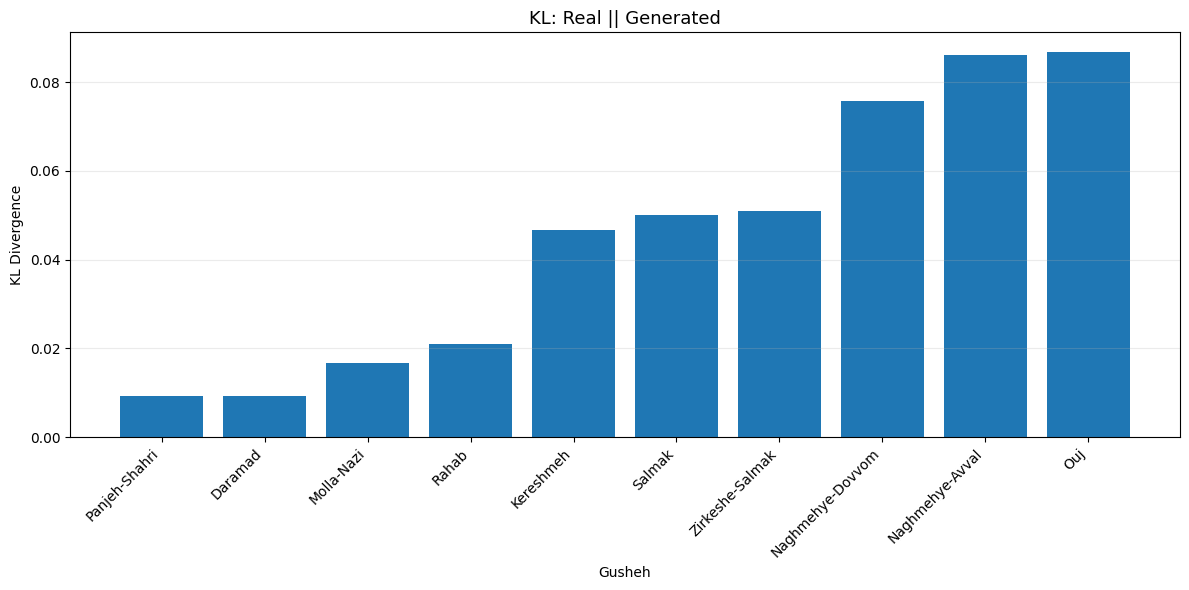

Saved: /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_KL_REAL_TO_GENERATED.png


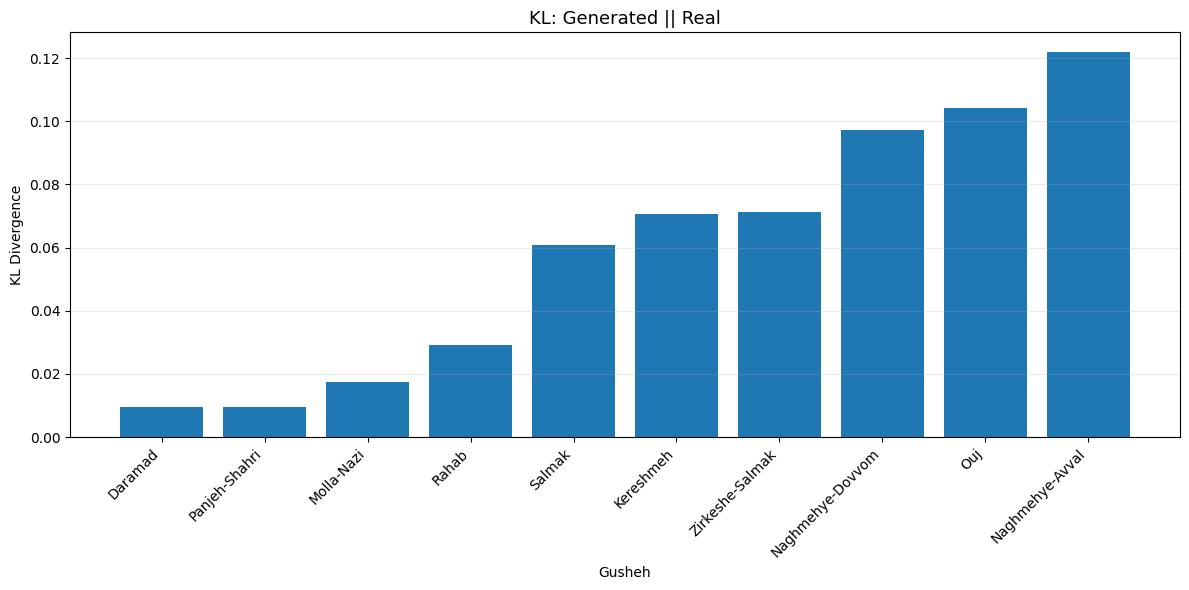

Saved: /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_KL_GENERATED_TO_REAL.png


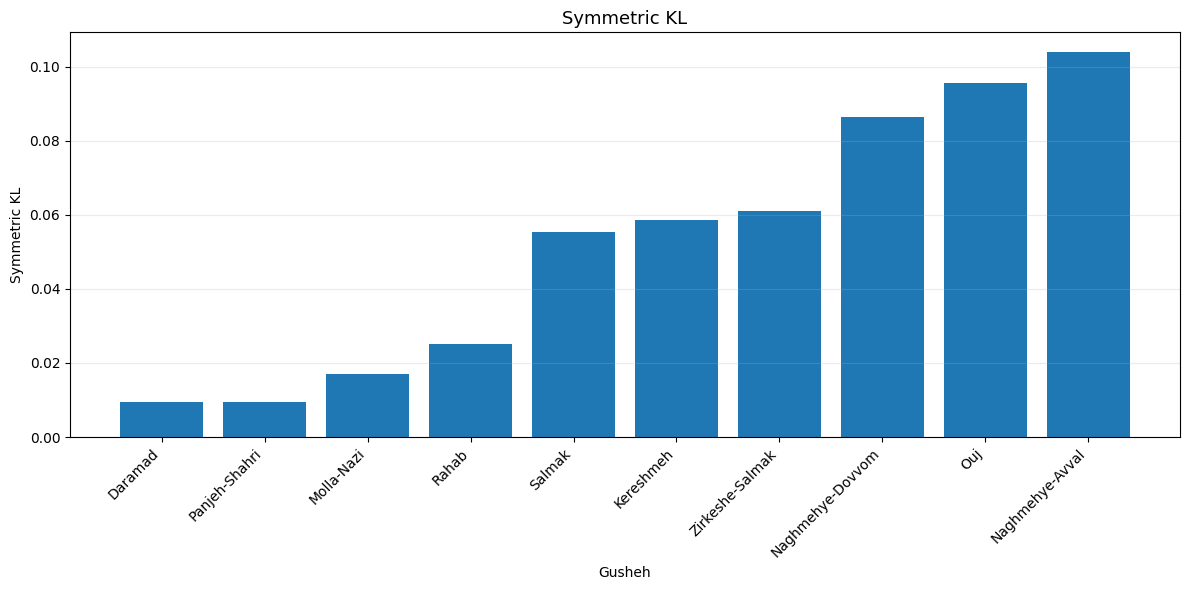

Saved: /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_SYMMETRIC_KL.png


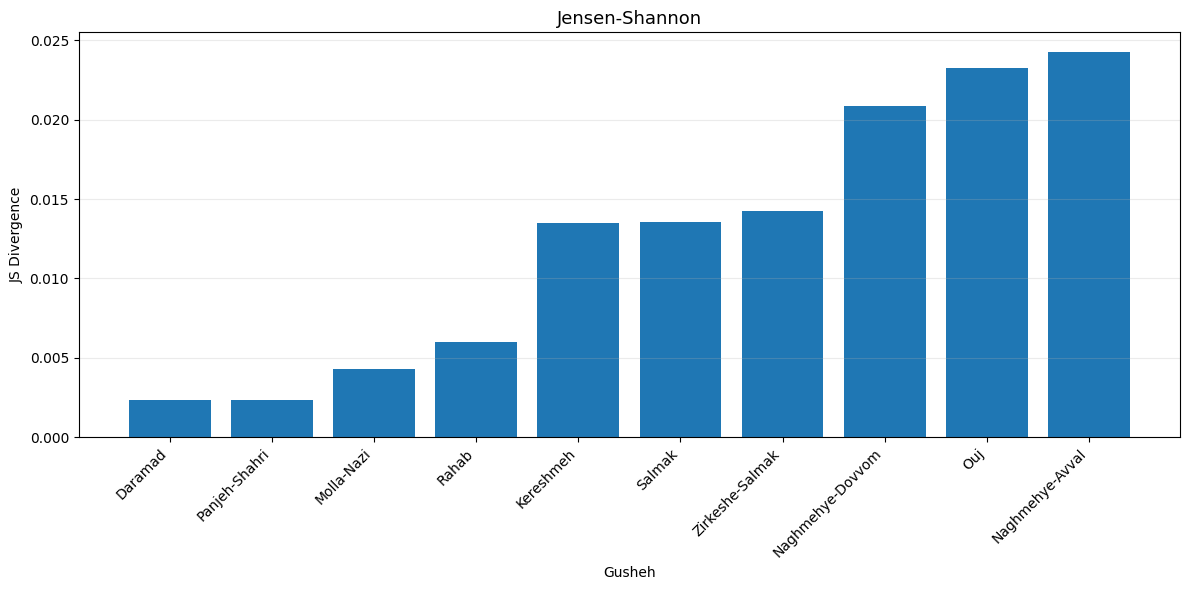

Saved: /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_JENSEN_SHANNON.png


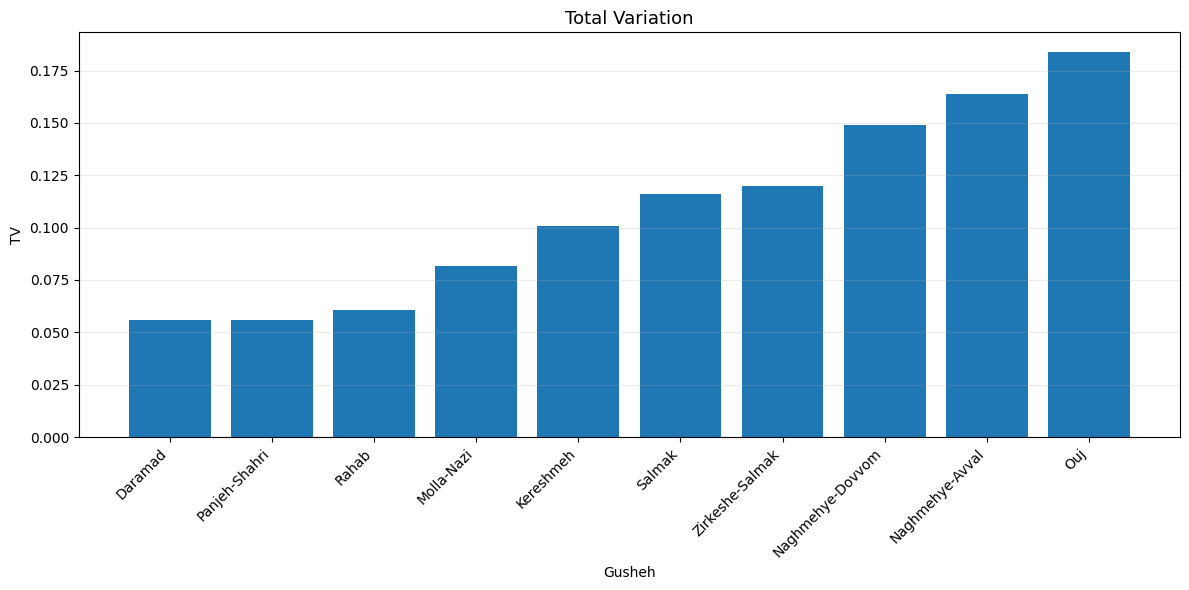

Saved: /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_TOTAL_VARIATION.png


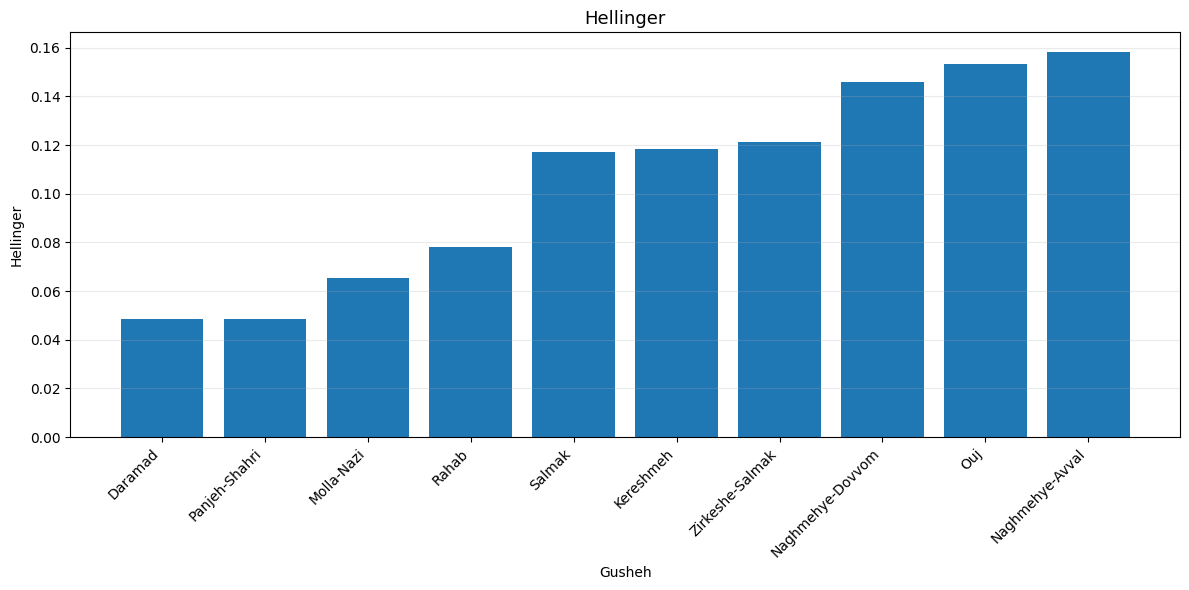

Saved: /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_HELLINGER.png


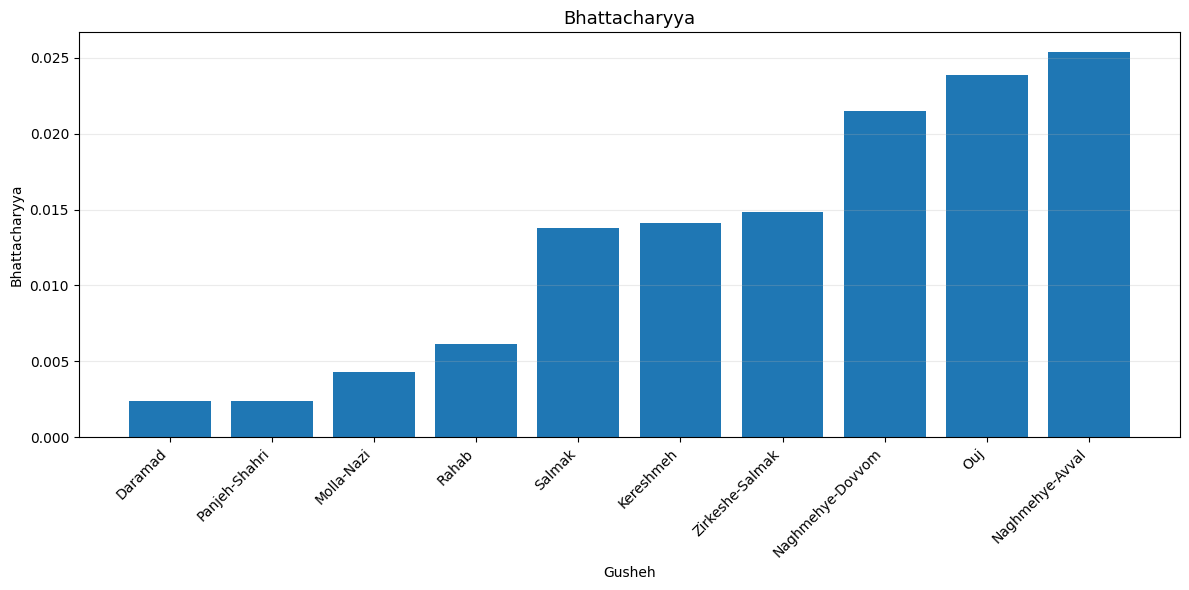

Saved: /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_BHATTACHARYYA.png


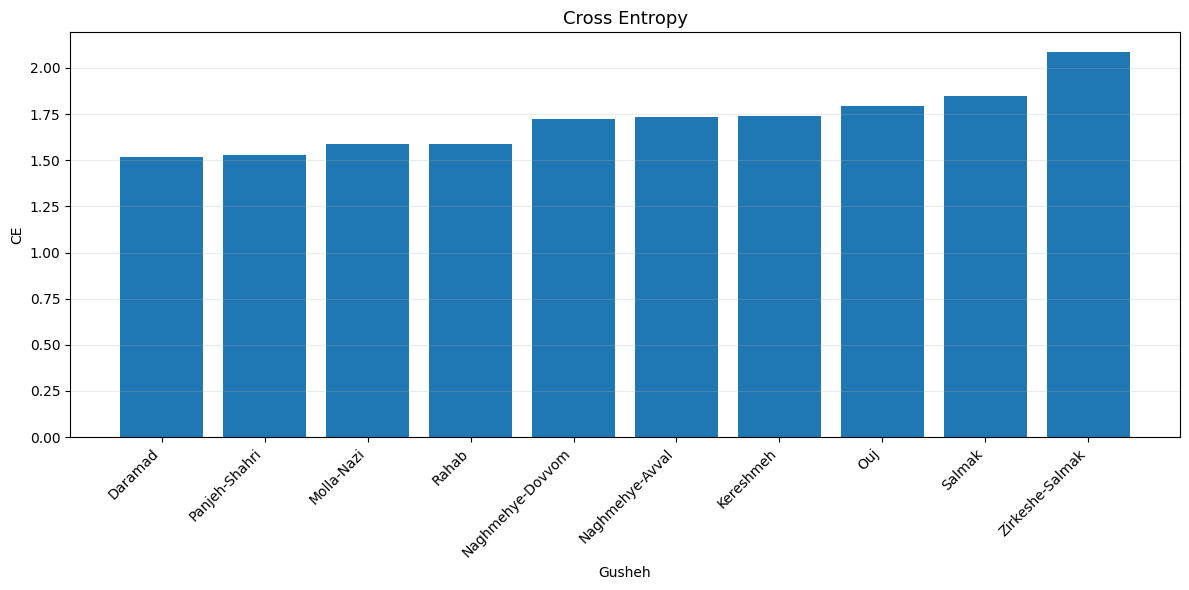

Saved: /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_CROSS_ENTROPY.png


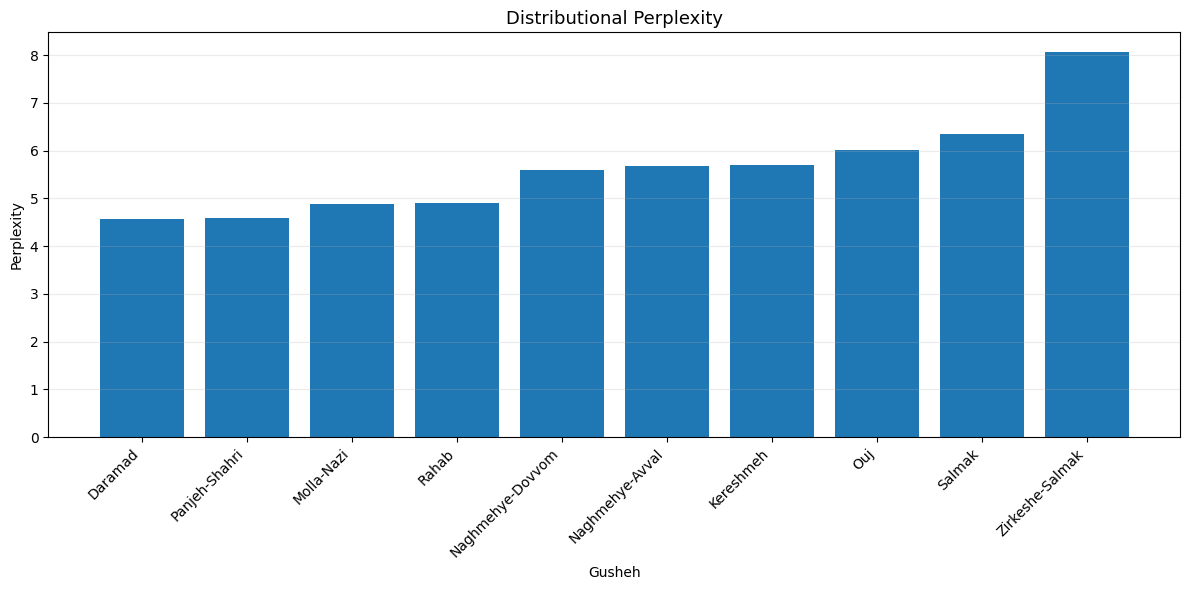

Saved: /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_DISTRIBUTIONAL_PERPLEXITY.png


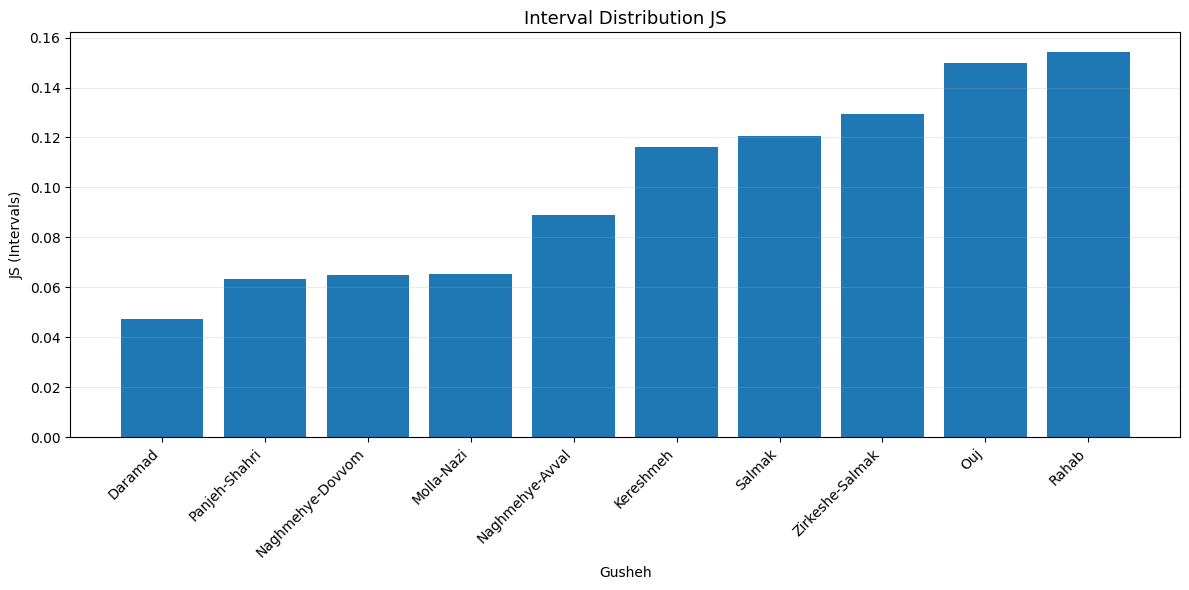

Saved: /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_JS_INTERVALS.png

MEAN DIVERGENCE ACROSS 10 GUSHEHS
KL_Real_to_Generated          : 0.045233
KL_Generated_to_Real          : 0.059220
Symmetric_KL                  : 0.052226
Jensen_Shannon                : 0.012463
Total_Variation               : 0.108819
Hellinger                     : 0.105498
Bhattacharyya                 : 0.012859
Cross_Entropy                 : 1.714536
Perplexity                    : 5.633445
JS_Intervals                  : 0.100050

ALL OUTPUT FILES

Main table   : /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_DISTRIBUTIONAL_DIVERGENCE.csv
JS ranking   : /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_JS_RANKING.csv
Pitch dists  : /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_PITCH_DISTRIBUTIONS.csv
Interval     : /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_INTERVAL_DISTRIBUTIONS.csv
Mean summary : /content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_DIVERGENCE_MEAN_SUMMARY.csv

ADAPTIVE BEAR DIVE

In [ ]:

# ==============================================================================
# BAYESIAN — ADAPTIVE BEAR DISTRIBUTIONAL DIVERGENCE
# ==============================================================================
#
# FINAL DISTRIBUTIONAL ANALYSIS
#
# Compares REAL gusheh pitch distributions against
# ADAPTIVE BEAR generated pitch distributions for all 10 gushehs.
#
# Metrics:
#   1. KL(Real || Generated)
#   2. KL(Generated || Real)
#   3. Symmetric KL
#   4. Jensen-Shannon Divergence
#   5. Total Variation Distance
#   6. Hellinger Distance
#   7. Bhattacharyya Distance
#   8. Cross Entropy
#   9. Perplexity
#  10. Interval Distribution JS divergence
# ==============================================================================

import os
import ast
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================

RESULT_DIR = "/content/BEAR_DISTRIBUTION_RESULTS"
os.makedirs(RESULT_DIR, exist_ok=True)

ALPHA = 0.5
EPS = 1e-15

N_MELODIES_EXPECTED = 1000
MELODY_LENGTH_EXPECTED = 64


# ==============================================================================
# 2. GUSHEHS
# ==============================================================================

GUSHEHS = {
    "Daramad":            "01 - Daramad.csv",
    "Panjeh-Shahri":      "02 - Panjehsheri.csv",
    "Kereshmeh":          "03 - Kereshmeh.csv",
    "Rahab":              "04 - Rahab.csv",
    "Ouj":                "05 - Ouj.csv",
    "Molla-Nazi":         "06 - Molla Nazi.csv",
    "Naghmehye-Avval":    "07 - Naghmehye avval.csv",
    "Naghmehye-Dovvom":   "08 - Naghmehye Dovvom.csv",
    "Zirkeshe-Salmak":    "09 - Zirkeshe Salmak.csv",
    "Salmak":             "10 - Salmak.csv",
}

PITCH_COLUMN = "Pitch / microtone style"


# ==============================================================================
# 3. HEADER
# ==============================================================================

print("=" * 78)
print("BAYESIAN — ADAPTIVE BEAR DISTRIBUTIONAL DIVERGENCE")
print("=" * 78)


# ==============================================================================
# 4. PITCH PARSER
# ==============================================================================

def parse_pitch_value(value):
    if pd.isna(value):
        return []
    value = str(value).strip()
    if not value:
        return []

    if value.startswith("[") and value.endswith("]"):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                result = []
                for item in parsed:
                    item = str(item).strip()
                    if item in ["", "[", "]"]:
                        continue
                    result.append(item)
                return result
        except Exception:
            pass

    value = value.replace("[", "").replace("]", "").strip()
    if not value:
        return []
    return [value]


# ==============================================================================
# 5. FIND ORIGINAL FILE
# ==============================================================================

ORIGINAL_SEARCH_DIRS = [
    "/content/ShourCorpus/ShourCorpus-main/Data sheets",
    "/content/ShourCorpus/ShourCorpus-main",
    "/content/ShourCorpus",
    "/content",
]


def find_original_file(filename):
    for directory in ORIGINAL_SEARCH_DIRS:
        if not os.path.exists(directory):
            continue
        path = os.path.join(directory, filename)
        if os.path.isfile(path):
            return path

    for directory in ORIGINAL_SEARCH_DIRS:
        if not os.path.exists(directory):
            continue
        matches = glob.glob(
            os.path.join(directory, "**", filename),
            recursive=True
        )
        if matches:
            return matches[0]

    return None


# ==============================================================================
# 6. LOAD REAL GUSHEHS
# ==============================================================================

print("\n" + "=" * 78)
print("LOADING ORIGINAL GUSHEHS")
print("=" * 78)

REAL_DATA = {}

for gusheh, filename in GUSHEHS.items():
    path = find_original_file(filename)
    if path is None:
        raise FileNotFoundError(f"Original file not found: {filename}")

    df = pd.read_csv(path)
    if PITCH_COLUMN not in df.columns:
        raise ValueError(f"Pitch column not found in {path}")

    sequence = []
    for value in df[PITCH_COLUMN]:
        sequence.extend(parse_pitch_value(value))

    if not sequence:
        raise ValueError(f"No pitches found for {gusheh}")

    REAL_DATA[gusheh] = sequence
    states = sorted(set(sequence))
    print(f"{gusheh:20s} | N = {len(sequence):4d} | States = {states}")


# ==============================================================================
# 7. GLOBAL VOCABULARY
# ==============================================================================

GLOBAL_STATES = sorted(
    set(p for seq in REAL_DATA.values() for p in seq)
)
print("\nGlobal real pitch vocabulary:")
print(GLOBAL_STATES)


# ==============================================================================
# 8. FUZZY FILE FINDING
# ==============================================================================

def normalize_name(text):
    text = str(text).lower()
    text = text.replace("_", "").replace("-", "").replace(" ", "")
    return text


def find_generated_file(gusheh):
    candidates = [
        f"ADAPTIVE_BEAR_{gusheh}_generated_melodies.csv",
        f"ADAPTIVE_BEAR_{gusheh}_generated.csv",
        f"{gusheh}_ADAPTIVE_BEAR_generated_melodies.csv",
        f"{gusheh}_adaptive_bear_generated_melodies.csv",
        f"{gusheh}_generated_melodies.csv",
        f"{gusheh}_generated.csv",
        f"adaptive_bear_{gusheh}_generated_melodies.csv",
        f"adaptive_bear_{gusheh}_generated.csv",
    ]

    for filename in candidates:
        path = os.path.join(RESULT_DIR, filename)
        if os.path.isfile(path):
            return path

    all_csv = glob.glob(os.path.join(RESULT_DIR, "*.csv"))
    gusheh_norm = normalize_name(gusheh)

    for path in all_csv:
        base = normalize_name(os.path.basename(path))
        if (
            "adaptivebear" in base
            and gusheh_norm in base
            and ("generated" in base or "melod" in base)
        ):
            return path

    for path in all_csv:
        base = normalize_name(os.path.basename(path))
        if (
            gusheh_norm in base
            and "generated" in base
            and "melod" in base
        ):
            return path

    return None


# ==============================================================================
# 9. STRICT FILE VALIDATION
# ==============================================================================

print("\n" + "=" * 78)
print("SEARCHING FOR ADAPTIVE BEAR GENERATED FILES")
print("=" * 78)

GENERATED_PATHS = {}
missing = []

for gusheh in GUSHEHS:
    path = find_generated_file(gusheh)
    if path is None:
        print(f"{gusheh:20s} | NOT FOUND")
        missing.append(gusheh)
    else:
        print(f"{gusheh:20s} | {os.path.basename(path)}")
        GENERATED_PATHS[gusheh] = path

if missing:
    raise RuntimeError("Missing generated files. Run generation first.")


# ==============================================================================
# 10. EXTRACT PITCHES
# ==============================================================================

def extract_generated_pitches(df, valid_states):
    valid_states = set(valid_states)
    generated = []

    note_columns = [
        c for c in df.columns
        if isinstance(c, str) and c.startswith("note_")
    ]

    if note_columns:
        for col in note_columns:
            for value in df[col]:
                parsed = parse_pitch_value(value)
                for token in parsed:
                    token = str(token).strip()
                    if token in valid_states:
                        generated.append(token)
        return generated

    for col in df.columns:
        for value in df[col]:
            parsed = parse_pitch_value(value)
            for token in parsed:
                token = str(token).strip()
                if token in valid_states:
                    generated.append(token)

    return generated


def load_generated_melodies(path, gusheh):
    df = pd.read_csv(path)
    if len(df) != N_MELODIES_EXPECTED:
        raise ValueError(
            f"{gusheh}: Expected {N_MELODIES_EXPECTED} melodies, found {len(df)}."
        )
    return df


# ==============================================================================
# 11. LOAD ALL GENERATED
# ==============================================================================

print("\n" + "=" * 78)
print("LOADING ADAPTIVE BEAR GENERATED MELODIES")
print("=" * 78)

GENERATED_DATA = {}
GENERATED_DFS = {}

for gusheh in GUSHEHS:
    df = load_generated_melodies(GENERATED_PATHS[gusheh], gusheh)
    valid_states = set(REAL_DATA[gusheh])
    pitches = extract_generated_pitches(df, valid_states)

    if len(pitches) == 0:
        raise ValueError(f"{gusheh}: No valid pitches found.")

    GENERATED_DATA[gusheh] = pitches
    GENERATED_DFS[gusheh] = df

    print(
        f"{gusheh:20s} | Melodies = {len(df):4d} | "
        f"Pitches = {len(pitches):6d} | Shape = {df.shape}"
    )


# ==============================================================================
# 12. DISTRIBUTIONS
# ==============================================================================

def smoothed_distribution(sequence, states, alpha=ALPHA):
    counts = {state: 0.0 for state in states}
    for pitch in sequence:
        if pitch in counts:
            counts[pitch] += 1.0
    values = np.array([counts[s] + alpha for s in states], dtype=float)
    values /= values.sum()
    return values


def interval_distribution(sequence, states):
    state_to_idx = {s: i for i, s in enumerate(states)}
    intervals = []
    for i in range(len(sequence) - 1):
        if sequence[i] in state_to_idx and sequence[i+1] in state_to_idx:
            idx1 = state_to_idx[sequence[i]]
            idx2 = state_to_idx[sequence[i+1]]
            intervals.append(abs(idx2 - idx1))
    if not intervals:
        return {}
    counts = Counter(intervals)
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}


# ==============================================================================
# 13. DIVERGENCE FUNCTIONS
# ==============================================================================

def kl_divergence(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = np.clip(p, EPS, None)
    q = np.clip(q, EPS, None)
    p /= p.sum()
    q /= q.sum()
    return float(np.sum(p * np.log(p / q)))


def jensen_shannon(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = np.clip(p, EPS, None)
    q = np.clip(q, EPS, None)
    p /= p.sum()
    q /= q.sum()
    m = 0.5 * (p + q)
    return 0.5 * kl_divergence(p, m) + 0.5 * kl_divergence(q, m)


def total_variation(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p /= p.sum()
    q /= q.sum()
    return float(0.5 * np.sum(np.abs(p - q)))


def hellinger_distance(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p /= p.sum()
    q /= q.sum()
    return float(np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2)))


def bhattacharyya_distance(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p /= p.sum()
    q /= q.sum()
    coefficient = np.sum(np.sqrt(p * q))
    coefficient = np.clip(coefficient, EPS, 1.0)
    return float(-np.log(coefficient))


def cross_entropy(p_real, q_generated):
    p = np.asarray(p_real, dtype=float)
    q = np.asarray(q_generated, dtype=float)
    p /= p.sum()
    q /= q.sum()
    q = np.clip(q, EPS, None)
    return float(-np.sum(p * np.log(q)))


def perplexity_from_cross_entropy(ce):
    return float(np.exp(ce))


# ==============================================================================
# 14. COMPUTE ALL METRICS
# ==============================================================================

print("\n" + "=" * 78)
print("COMPUTING DIVERGENCES")
print("=" * 78)

results = []
distribution_rows = []
interval_rows = []

for gusheh in GUSHEHS:
    real_sequence = REAL_DATA[gusheh]
    generated_sequence = GENERATED_DATA[gusheh]

    local_states = sorted(set(real_sequence) | set(generated_sequence))

    p_real = smoothed_distribution(real_sequence, local_states, ALPHA)
    p_generated = smoothed_distribution(generated_sequence, local_states, ALPHA)

    kl_rg = kl_divergence(p_real, p_generated)
    kl_gr = kl_divergence(p_generated, p_real)
    sym_kl = 0.5 * (kl_rg + kl_gr)
    js = jensen_shannon(p_real, p_generated)
    tv = total_variation(p_real, p_generated)
    hell = hellinger_distance(p_real, p_generated)
    bhat = bhattacharyya_distance(p_real, p_generated)
    ce = cross_entropy(p_real, p_generated)
    ppl = perplexity_from_cross_entropy(ce)

    real_intervals = interval_distribution(real_sequence, local_states)
    gen_intervals = interval_distribution(generated_sequence, local_states)
    all_intervals = sorted(set(real_intervals) | set(gen_intervals))

    if all_intervals:
        p_real_int = np.array(
            [real_intervals.get(k, 0) for k in all_intervals], dtype=float
        )
        p_gen_int = np.array(
            [gen_intervals.get(k, 0) for k in all_intervals], dtype=float
        )
        p_real_int = np.clip(p_real_int, EPS, None)
        p_gen_int = np.clip(p_gen_int, EPS, None)
        p_real_int /= p_real_int.sum()
        p_gen_int /= p_gen_int.sum()
        js_intervals = jensen_shannon(p_real_int, p_gen_int)
    else:
        js_intervals = np.nan

    results.append({
        "Gusheh": gusheh,
        "Real_N": len(real_sequence),
        "Generated_N": len(generated_sequence),
        "Number_of_States": len(local_states),
        "KL_Real_to_Generated": kl_rg,
        "KL_Generated_to_Real": kl_gr,
        "Symmetric_KL": sym_kl,
        "Jensen_Shannon": js,
        "Total_Variation": tv,
        "Hellinger": hell,
        "Bhattacharyya": bhat,
        "Cross_Entropy": ce,
        "Perplexity": ppl,
        "JS_Intervals": js_intervals,
    })

    for i, state in enumerate(local_states):
        distribution_rows.append({
            "Gusheh": gusheh,
            "Pitch": state,
            "Real_Probability": p_real[i],
            "Adaptive_Bear_Probability": p_generated[i],
            "Absolute_Difference": abs(p_real[i] - p_generated[i]),
        })

    for k in all_intervals:
        interval_rows.append({
            "Gusheh": gusheh,
            "Interval": k,
            "Real_Probability": real_intervals.get(k, 0.0),
            "Adaptive_Bear_Probability": gen_intervals.get(k, 0.0),
        })

    print(f"\n{gusheh}")
    print(f"  Real N          : {len(real_sequence)}")
    print(f"  Generated N     : {len(generated_sequence)}")
    print(f"  States          : {len(local_states)}")
    print(f"  KL R||G         : {kl_rg:.6f}")
    print(f"  KL G||R         : {kl_gr:.6f}")
    print(f"  Symmetric KL    : {sym_kl:.6f}")
    print(f"  Jensen-Shannon  : {js:.6f}")
    print(f"  Total Variation : {tv:.6f}")
    print(f"  Hellinger       : {hell:.6f}")
    print(f"  Bhattacharyya   : {bhat:.6f}")
    print(f"  Cross Entropy   : {ce:.6f}")
    print(f"  Perplexity      : {ppl:.6f}")
    print(f"  JS Intervals    : {js_intervals:.6f}")


# ==============================================================================
# 15. DATAFRAMES
# ==============================================================================

results_df = pd.DataFrame(results)
distribution_df = pd.DataFrame(distribution_rows)
interval_df = pd.DataFrame(interval_rows)

ranking_df = results_df.sort_values("Jensen_Shannon", ascending=True).reset_index(drop=True)
ranking_df.insert(0, "JS_Rank", np.arange(1, len(ranking_df) + 1))


# ==============================================================================
# 16. SAVE CSV
# ==============================================================================

main_csv = os.path.join(RESULT_DIR, "ADAPTIVE_BEAR_DISTRIBUTIONAL_DIVERGENCE.csv")
ranking_csv = os.path.join(RESULT_DIR, "ADAPTIVE_BEAR_JS_RANKING.csv")
distribution_csv = os.path.join(RESULT_DIR, "ADAPTIVE_BEAR_PITCH_DISTRIBUTIONS.csv")
interval_csv = os.path.join(RESULT_DIR, "ADAPTIVE_BEAR_INTERVAL_DISTRIBUTIONS.csv")

results_df.to_csv(main_csv, index=False)
ranking_df.to_csv(ranking_csv, index=False)
distribution_df.to_csv(distribution_csv, index=False)
interval_df.to_csv(interval_csv, index=False)


# ==============================================================================
# 17. PRINT TABLES
# ==============================================================================

print("\n" + "=" * 78)
print("FINAL DIVERGENCE RESULTS")
print("=" * 78)

display_cols = [
    "Gusheh", "KL_Real_to_Generated", "KL_Generated_to_Real",
    "Symmetric_KL", "Jensen_Shannon", "Total_Variation",
    "Hellinger", "Bhattacharyya", "Cross_Entropy", "Perplexity",
    "JS_Intervals",
]
print(results_df[display_cols].round(6).to_string(index=False))

print("\n" + "=" * 78)
print("JENSEN-SHANNON RANKING")
print("=" * 78)
print(ranking_df[["JS_Rank", "Gusheh", "Jensen_Shannon"]].round(6).to_string(index=False))


# ==============================================================================
# 18. PLOT FUNCTION
# ==============================================================================

def save_bar_plot(df, metric, title, filename, ylabel=None):
    plot_df = df.sort_values(metric, ascending=True)
    plt.figure(figsize=(12, 6))
    plt.bar(plot_df["Gusheh"], plot_df[metric])
    plt.title(title, fontsize=13)
    plt.ylabel(ylabel if ylabel else metric)
    plt.xlabel("Gusheh")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    path = os.path.join(RESULT_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


# ==============================================================================
# 19. PLOTS
# ==============================================================================

plot_specs = [
    ("KL_Real_to_Generated", "KL: Real || Generated",
     "ADAPTIVE_BEAR_KL_REAL_TO_GENERATED.png", "KL Divergence"),
    ("KL_Generated_to_Real", "KL: Generated || Real",
     "ADAPTIVE_BEAR_KL_GENERATED_TO_REAL.png", "KL Divergence"),
    ("Symmetric_KL", "Symmetric KL",
     "ADAPTIVE_BEAR_SYMMETRIC_KL.png", "Symmetric KL"),
    ("Jensen_Shannon", "Jensen-Shannon",
     "ADAPTIVE_BEAR_JENSEN_SHANNON.png", "JS Divergence"),
    ("Total_Variation", "Total Variation",
     "ADAPTIVE_BEAR_TOTAL_VARIATION.png", "TV"),
    ("Hellinger", "Hellinger",
     "ADAPTIVE_BEAR_HELLINGER.png", "Hellinger"),
    ("Bhattacharyya", "Bhattacharyya",
     "ADAPTIVE_BEAR_BHATTACHARYYA.png", "Bhattacharyya"),
    ("Cross_Entropy", "Cross Entropy",
     "ADAPTIVE_BEAR_CROSS_ENTROPY.png", "CE"),
    ("Perplexity", "Distributional Perplexity",
     "ADAPTIVE_BEAR_DISTRIBUTIONAL_PERPLEXITY.png", "Perplexity"),
    ("JS_Intervals", "Interval Distribution JS",
     "ADAPTIVE_BEAR_JS_INTERVALS.png", "JS (Intervals)"),
]

for metric, title, filename, ylabel in plot_specs:
    save_bar_plot(results_df, metric, title, filename, ylabel)


# ==============================================================================
# 20. MEAN METRICS
# ==============================================================================

print("\n" + "=" * 78)
print("MEAN DIVERGENCE ACROSS 10 GUSHEHS")
print("=" * 78)

metric_columns = [
    "KL_Real_to_Generated", "KL_Generated_to_Real", "Symmetric_KL",
    "Jensen_Shannon", "Total_Variation", "Hellinger", "Bhattacharyya",
]

mean_metrics = results_df[metric_columns + ["Cross_Entropy", "Perplexity", "JS_Intervals"]].mean()

for metric, value in mean_metrics.items():
    print(f"{metric:30s}: {value:.6f}")

mean_summary = pd.DataFrame({
    "Metric": mean_metrics.index,
    "Mean": mean_metrics.values,
})

mean_summary_path = os.path.join(
    RESULT_DIR, "ADAPTIVE_BEAR_DIVERGENCE_MEAN_SUMMARY.csv"
)
mean_summary.to_csv(mean_summary_path, index=False)


# ==============================================================================
# 21. FILE REPORT
# ==============================================================================

print("\n" + "=" * 78)
print("ALL OUTPUT FILES")
print("=" * 78)
print(f"\nMain table   : {main_csv}")
print(f"JS ranking   : {ranking_csv}")
print(f"Pitch dists  : {distribution_csv}")
print(f"Interval     : {interval_csv}")
print(f"Mean summary : {mean_summary_path}")

print("\n" + "=" * 78)
print("ADAPTIVE BEAR DIVERGENCE ANALYSIS COMPLETE")
print("=" * 78)

In [ ]:

import pandas as pd

print("=== MEAN SUMMARY ===")
print(pd.read_csv("/content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_DIVERGENCE_MEAN_SUMMARY.csv").to_string(index=False))

print("\n=== PER-GUSHEH ===")
print(pd.read_csv("/content/BEAR_DISTRIBUTION_RESULTS/ADAPTIVE_BEAR_DISTRIBUTIONAL_DIVERGENCE.csv").to_string(index=False))

=== MEAN SUMMARY ===
              Metric     Mean
KL_Real_to_Generated 0.045233
KL_Generated_to_Real 0.059220
        Symmetric_KL 0.052226
      Jensen_Shannon 0.012463
     Total_Variation 0.108819
           Hellinger 0.105498
       Bhattacharyya 0.012859
       Cross_Entropy 1.714536
          Perplexity 5.633445
        JS_Intervals 0.100050

=== PER-GUSHEH ===
          Gusheh  Real_N  Generated_N  Number_of_States  KL_Real_to_Generated  KL_Generated_to_Real  Symmetric_KL  Jensen_Shannon  Total_Variation  Hellinger  Bhattacharyya  Cross_Entropy  Perplexity  JS_Intervals
         Daramad      63        64000                 5              0.009171              0.009645      0.009408        0.002347         0.055767   0.048470       0.002352       1.519306    4.569053      0.047453
   Panjeh-Shahri      67        64000                 5              0.009165              0.009672      0.009419        0.002350         0.056035   0.048500       0.002355       1.525683    4.598284  

In [ ]:

import os, ast, glob
import pandas as pd

GUSHEHS = {
    "Daramad": "01 - Daramad.csv",
    "Panjeh-Shahri": "02 - Panjehsheri.csv",
    # ... بقیه
}

DATA_DIR = "/content/ShourCorpus/ShourCorpus-main/Data sheets"
PITCH_COLUMN = "Pitch / microtone style"

def parse_pitch_value(v):
    if pd.isna(v): return []
    v = str(v).strip()
    if not v: return []
    if v.startswith("[") and v.endswith("]"):
        try:
            p = ast.literal_eval(v)
            if isinstance(p, list):
                return [str(x).strip() for x in p if str(x).strip()]
        except: pass
    v = v.replace("[","").replace("]","").strip()
    return [v] if v else []

rows = []
for g, f in GUSHEHS.items():
    df = pd.read_csv(os.path.join(DATA_DIR, f))
    seq = []
    for v in df[PITCH_COLUMN]:
        seq.extend(parse_pitch_value(v))

    T = len(seq)
    states = sorted(set(seq))

    ctx1 = set(seq[i] for i in range(T-1))
    ctx2 = set((seq[i-1], seq[i]) for i in range(1, T-1))
    ctx3 = set((seq[i-2], seq[i-1], seq[i]) for i in range(2, T-1))

    rows.append({
        "Gusheh": g,
        "N": T,
        "Unique_Pitches": len(states),
        "Order1_Contexts": len(ctx1),
        "Order2_Contexts": len(ctx2),
        "Order3_Contexts": len(ctx3),
    })

desc_df = pd.DataFrame(rows)
print(desc_df.to_string(index=False))

       Gusheh  N  Unique_Pitches  Order1_Contexts  Order2_Contexts  Order3_Contexts
      Daramad 63               5                5               16               30
Panjeh-Shahri 67               5                5               16               29


In [ ]:
print(desc_df.to_string(index=False))

       Gusheh  N  Unique_Pitches  Order1_Contexts  Order2_Contexts  Order3_Contexts
      Daramad 63               5                5               16               30
Panjeh-Shahri 67               5                5               16               29


In [ ]:

import os
import ast
import pandas as pd

DATA_DIR = "/content/ShourCorpus/ShourCorpus-main/Data sheets"
PITCH_COLUMN = "Pitch / microtone style"

GUSHEHS = {
    "Daramad":            "01 - Daramad.csv",
    "Panjeh-Shahri":      "02 - Panjehsheri.csv",
    "Kereshmeh":          "03 - Kereshmeh.csv",
    "Rahab":              "04 - Rahab.csv",
    "Ouj":                "05 - Ouj.csv",
    "Molla-Nazi":         "06 - Molla Nazi.csv",
    "Naghmehye-Avval":    "07 - Naghmehye avval.csv",
    "Naghmehye-Dovvom":   "08 - Naghmehye Dovvom.csv",
    "Zirkeshe-Salmak":    "09 - Zirkeshe Salmak.csv",
    "Salmak":             "10 - Salmak.csv",
}

def parse_pitch_value(v):
    if pd.isna(v): return []
    v = str(v).strip()
    if not v: return []
    if v.startswith("[") and v.endswith("]"):
        try:
            p = ast.literal_eval(v)
            if isinstance(p, list):
                return [str(x).strip() for x in p if str(x).strip()]
        except: pass
    v = v.replace("[","").replace("]","").strip()
    return [v] if v else []

rows = []
for g, f in GUSHEHS.items():
    path = os.path.join(DATA_DIR, f)
    if not os.path.exists(path):
        print(f"MISSING: {f}")
        continue
    df = pd.read_csv(path)
    seq = []
    for v in df[PITCH_COLUMN]:
        seq.extend(parse_pitch_value(v))

    T = len(seq)
    states = sorted(set(seq))

    ctx1 = set(seq[i] for i in range(T-1))
    ctx2 = set((seq[i-1], seq[i]) for i in range(1, T-1))
    ctx3 = set((seq[i-2], seq[i-1], seq[i]) for i in range(2, T-1))

    rows.append({
        "Gusheh": g,
        "N": T,
        "Unique_Pitches": len(states),
        "Order1_Contexts": len(ctx1),
        "Order2_Contexts": len(ctx2),
        "Order3_Contexts": len(ctx3),
    })

desc_df = pd.DataFrame(rows)

# Print each row on its own line
print("=" * 90)
print(f"{'Gusheh':20s} {'N':>5s} {'Unique':>7s} {'Order1':>7s} {'Order2':>7s} {'Order3':>7s}")
print("=" * 90)
for _, r in desc_df.iterrows():
    print(f"{r['Gusheh']:20s} {r['N']:5d} {r['Unique_Pitches']:7d} "
          f"{r['Order1_Contexts']:7d} {r['Order2_Contexts']:7d} {r['Order3_Contexts']:7d}")
print("=" * 90)
print(f"{'Total':20s} {desc_df['N'].sum():5d} {11:7d} "
      f"{desc_df['Order1_Contexts'].sum():7d} {desc_df['Order2_Contexts'].sum():7d} "
      f"{desc_df['Order3_Contexts'].sum():7d}")
print("=" * 90)

Gusheh                   N  Unique  Order1  Order2  Order3
Daramad                 63       5       5      16      30
Panjeh-Shahri           67       5       5      16      29
Kereshmeh              164       7       7      26      57
Rahab                  112       6       6      13      23
Ouj                    167       8       8      26      60
Molla-Nazi             125       6       6      21      40
Naghmehye-Avval        269       9       9      34      62
Naghmehye-Dovvom       189       8       8      30      52
Zirkeshe-Salmak        305      10      10      33      71
Salmak                 166       8       8      22      45
Total                 1627      11      72     237     469


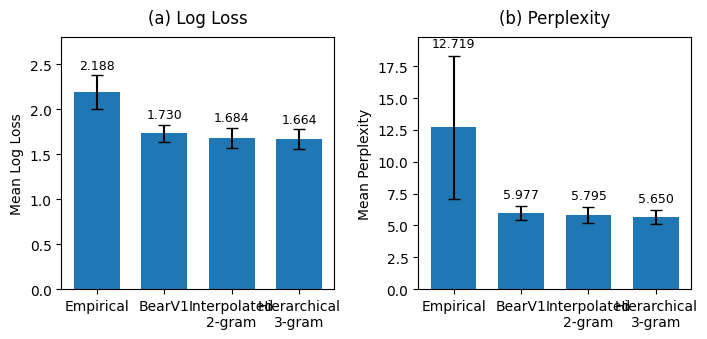

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t

models = ["Empirical", "BearV1", "Interpolated\n2-gram", "Hierarchical\n3-gram"]
mean_ll = np.array([2.1878, 1.7305, 1.6843, 1.6638])
sd_ll = np.array([0.6624, 0.3481, 0.3937, 0.3886])
mean_ppl = np.array([12.7193, 5.9771, 5.7949, 5.6502])
sd_ppl = np.array([19.7518, 1.9516, 2.1533, 1.9254])

N_SPLITS = 50
T_CRIT = t.ppf(0.975, df=N_SPLITS - 1)
ci_ll = T_CRIT * sd_ll / np.sqrt(N_SPLITS)
ci_ppl = T_CRIT * sd_ppl / np.sqrt(N_SPLITS)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.5))
x = np.arange(len(models))

ax = axes[0]
ax.bar(x, mean_ll, yerr=ci_ll, capsize=4, width=0.68)
ax.set_title("(a) Log Loss", pad=10)
ax.set_ylabel("Mean Log Loss")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, max(mean_ll + ci_ll) * 1.18)
for i, value in enumerate(mean_ll):
    ax.text(i, mean_ll[i] + ci_ll[i] + 0.04, f"{value:.3f}",
            ha="center", va="bottom", fontsize=9)

ax = axes[1]
ax.bar(x, mean_ppl, yerr=ci_ppl, capsize=4, width=0.68)
ax.set_title("(b) Perplexity", pad=10)
ax.set_ylabel("Mean Perplexity")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, max(mean_ppl + ci_ppl) * 1.08)
for i, value in enumerate(mean_ppl):
    ax.text(i, mean_ppl[i] + ci_ppl[i] + 0.4, f"{value:.3f}",
            ha="center", va="bottom", fontsize=9)

fig.tight_layout()
fig.savefig("/content/op1.pdf", bbox_inches="tight")
fig.savefig("/content/op1.png", bbox_inches="tight")
plt.show()

In [ ]:

# ============================================================
# 🐻 BEAR + BASELINES (Jelinek-Mercer, Witten-Bell)
# ============================================================
# Unified nested validation: 6 models on 50 unique splits.
#
# Models:
#  1. Empirical
#  2. JelinekMercer   (fixed λ, order 2)
#  3. WittenBell      (adaptive λ based on distinct continuations)
#  4. BearV1          (bigram, Dirichlet)
#  5. BearInterpolated2gram (adaptive λ, order 2)
#  6. BearHierarchical3gram (adaptive λ, order 3)
# ============================================================

import os
import ast
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from scipy import stats


# ============================================================
# CONFIG
# ============================================================

# Auto-detect data directory
CANDIDATES = [
    "/content/ShourCorpus/ShourCorpus-main/Data sheets",
    "/content/ShourCorpus/ShourCorpus-main",
    "/content/ShourCorpus",
    "/content",
]

DATA_DIR = None
for d in CANDIDATES:
    if os.path.exists(os.path.join(d, "01 - Daramad.csv")):
        DATA_DIR = d
        break

if DATA_DIR is None:
    raise FileNotFoundError("Could not find data directory")

print(f"Using DATA_DIR = {DATA_DIR}")
OUT_DIR = "/content/BEAR_DISTRIBUTION_RESULTS"
os.makedirs(OUT_DIR, exist_ok=True)

ALPHA = 0.5
KAPPAS = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]
LAMBDAS = [0.5, 0.6, 0.7, 0.8, 0.9]

OUTER_TRAIN_RATIOS = [0.70, 0.75, 0.80, 0.85, 0.90]
INNER_TRAIN_RATIO = 0.80

GUSHEHS = {
    "Daramad":            "01 - Daramad.csv",
    "Panjeh-Shahri":      "02 - Panjehsheri.csv",
    "Kereshmeh":          "03 - Kereshmeh.csv",
    "Rahab":              "04 - Rahab.csv",
    "Ouj":                "05 - Ouj.csv",
    "Molla-Nazi":         "06 - Molla Nazi.csv",
    "Naghmehye-Avval":    "07 - Naghmehye avval.csv",
    "Naghmehye-Dovvom":   "08 - Naghmehye Dovvom.csv",
    "Zirkeshe-Salmak":    "09 - Zirkeshe Salmak.csv",
    "Salmak":             "10 - Salmak.csv",
}

PITCH_COL = "Pitch / microtone style"


# ============================================================
# PARSER
# ============================================================

def parse_pitch_value(value):
    if pd.isna(value):
        return []
    value = str(value).strip()
    if not value:
        return []
    if value.startswith("[") and value.endswith("]"):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return [str(x).strip() for x in parsed if str(x).strip() not in ["", "[", "]"]]
        except Exception:
            pass
    value = value.replace("[", "").replace("]", "").strip()
    if value in ["", "[", "]"]:
        return []
    return [value]


# ============================================================
# LOAD DATA
# ============================================================

print("=" * 75)
print("LOADING GUSHEHS")
print("=" * 75)

gusheh_sequences = {}

for gusheh, filename in GUSHEHS.items():
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path)
    sequence = []
    for value in df[PITCH_COL]:
        sequence.extend(parse_pitch_value(value))
    gusheh_sequences[gusheh] = sequence
    print(f"{gusheh:18s} | N = {len(sequence):4d} | States = {len(set(sequence))}")


# ============================================================
# HELPERS
# ============================================================

def normalize_probs(counts, states, alpha=ALPHA):
    values = np.array([counts.get(s, 0) + alpha for s in states], dtype=float)
    return values / values.sum()


def split_sequence(seq, ratio):
    n = len(seq)
    split = int(n * ratio)
    return seq[:split], seq[split:]


# ============================================================
# BUILDERS
# ============================================================

def build_empirical(train_seq, states):
    counts = Counter(train_seq)
    probs = normalize_probs(counts, states)
    return dict(zip(states, probs))


def build_bear_v1(train_seq, states):
    counts = defaultdict(Counter)
    for i in range(len(train_seq) - 1):
        counts[train_seq[i]][train_seq[i+1]] += 1
    return {c: dict(zip(states, normalize_probs(counts[c], states))) for c in states}


def build_bear_2gram(train_seq, states):
    counts = defaultdict(Counter)
    ctx_counts = Counter()
    for i in range(len(train_seq) - 2):
        ctx = (train_seq[i], train_seq[i+1])
        counts[ctx][train_seq[i+2]] += 1
        ctx_counts[ctx] += 1
    probs = {ctx: dict(zip(states, normalize_probs(counts[ctx], states))) for ctx in counts}
    return probs, ctx_counts, counts


def build_bear_3gram(train_seq, states):
    counts = defaultdict(Counter)
    ctx_counts = Counter()
    for i in range(len(train_seq) - 3):
        ctx = (train_seq[i], train_seq[i+1], train_seq[i+2])
        counts[ctx][train_seq[i+3]] += 1
        ctx_counts[ctx] += 1
    probs = {ctx: dict(zip(states, normalize_probs(counts[ctx], states))) for ctx in counts}
    return probs, ctx_counts, counts


# ============================================================
# EVALUATORS
# ============================================================

def _logloss(probs):
    probs = np.clip(np.asarray(probs, dtype=float), 1e-15, None)
    return float(-np.mean(np.log(probs)))


def evaluate_empirical(test, emp, states):
    probs = [emp.get(t, 1/len(states)) for t in test]
    return _logloss(probs)


def evaluate_v1(test, v1, states):
    probs = []
    for i in range(1, len(test)):
        p = v1[test[i-1]].get(test[i], 1/len(states))
        probs.append(p)
    return _logloss(probs) if probs else np.nan


def evaluate_interpolated(test, v1, p2, c2, states, kappa):
    """Bear interpolated 2-gram: adaptive lambda."""
    probs = []
    for i in range(2, len(test)):
        ctx = (test[i-2], test[i-1])
        c1 = test[i-1]
        nxt = test[i]
        p_bi = v1[c1].get(nxt, 1/len(states))
        if ctx in p2:
            p_tri = p2[ctx].get(nxt, 1/len(states))
            n = c2[ctx]
            lam = n / (n + kappa)
        else:
            p_tri = p_bi
            lam = 0.0
        p = lam * p_tri + (1 - lam) * p_bi
        probs.append(p)
    return _logloss(probs) if probs else np.nan


def evaluate_hierarchical(test, v1, p2, c2, p3, c3, states, k2, k3):
    """Bear hierarchical 3-gram: two-level adaptive interpolation."""
    probs = []
    for i in range(3, len(test)):
        c1 = test[i-1]
        ctx2 = (test[i-2], test[i-1])
        ctx3 = (test[i-3], test[i-2], test[i-1])
        nxt = test[i]
        p_bi = v1[c1].get(nxt, 1/len(states))

        if ctx2 in p2:
            p_tri = p2[ctx2].get(nxt, 1/len(states))
            n2 = c2[ctx2]
            lam2 = n2 / (n2 + k2)
        else:
            p_tri = p_bi
            lam2 = 0.0
        p23 = lam2 * p_tri + (1 - lam2) * p_bi

        if ctx3 in p3:
            p_4 = p3[ctx3].get(nxt, 1/len(states))
            n3 = c3[ctx3]
            lam3 = n3 / (n3 + k3)
        else:
            p_4 = p23
            lam3 = 0.0
        p = lam3 * p_4 + (1 - lam3) * p23
        probs.append(p)
    return _logloss(probs) if probs else np.nan


def evaluate_jelinek_mercer(test, v1, p2, states, lam):
    """Jelinek-Mercer: P = lam * P_trigram_ML + (1-lam) * P_bigram_ML."""
    probs = []
    for i in range(2, len(test)):
        ctx = (test[i-2], test[i-1])
        c1 = test[i-1]
        nxt = test[i]
        p_bi = v1[c1].get(nxt, 1/len(states))
        if ctx in p2:
            p_tri = p2[ctx].get(nxt, 1/len(states))
            p = lam * p_tri + (1 - lam) * p_bi
        else:
            p = p_bi
        probs.append(p)
    return _logloss(probs) if probs else np.nan


def evaluate_witten_bell(test, v1, p2, c2, types2, states):
    """Witten-Bell: lam(c) = N(c) / (N(c) + T(c))."""
    probs = []
    for i in range(2, len(test)):
        ctx = (test[i-2], test[i-1])
        c1 = test[i-1]
        nxt = test[i]
        p_bi = v1[c1].get(nxt, 1/len(states))
        if ctx in p2:
            p_tri = p2[ctx].get(nxt, 1/len(states))
            n = c2[ctx]
            T = types2[ctx]
            lam = n / (n + T)
            p = lam * p_tri + (1 - lam) * p_bi
        else:
            p = p_bi
        probs.append(p)
    return _logloss(probs) if probs else np.nan


# ============================================================
# INNER VALIDATION (SELECT HYPERPARAMETERS)
# ============================================================

def select_kappa_i2(outer_train, states):
    inner_tr, inner_val = split_sequence(outer_train, INNER_TRAIN_RATIO)
    inner_states = sorted(set(inner_tr))
    inner_val = [x for x in inner_val if x in inner_states]
    if len(inner_val) < 3:
        return 2.0
    v1 = build_bear_v1(inner_tr, inner_states)
    p2, c2, _ = build_bear_2gram(inner_tr, inner_states)
    best_ll, best = np.inf, 2.0
    for k in KAPPAS:
        ll = evaluate_interpolated(inner_val, v1, p2, c2, inner_states, k)
        if ll < best_ll:
            best_ll, best = ll, k
    return best


def select_kappa_h3(outer_train, states):
    inner_tr, inner_val = split_sequence(outer_train, INNER_TRAIN_RATIO)
    inner_states = sorted(set(inner_tr))
    inner_val = [x for x in inner_val if x in inner_states]
    if len(inner_val) < 4:
        return 2.0, 4.0
    v1 = build_bear_v1(inner_tr, inner_states)
    p2, c2, _ = build_bear_2gram(inner_tr, inner_states)
    p3, c3, _ = build_bear_3gram(inner_tr, inner_states)
    best_ll, best = np.inf, (2.0, 4.0)
    for k2 in KAPPAS:
        for k3 in KAPPAS:
            ll = evaluate_hierarchical(inner_val, v1, p2, c2, p3, c3,
                                        inner_states, k2, k3)
            if ll < best_ll:
                best_ll, best = ll, (k2, k3)
    return best


def select_lambda_jm(outer_train, states):
    inner_tr, inner_val = split_sequence(outer_train, INNER_TRAIN_RATIO)
    inner_states = sorted(set(inner_tr))
    inner_val = [x for x in inner_val if x in inner_states]
    if len(inner_val) < 3:
        return 0.7
    v1 = build_bear_v1(inner_tr, inner_states)
    p2, c2, _ = build_bear_2gram(inner_tr, inner_states)
    best_ll, best = np.inf, 0.7
    for lam in LAMBDAS:
        ll = evaluate_jelinek_mercer(inner_val, v1, p2, inner_states, lam)
        if ll < best_ll:
            best_ll, best = ll, lam
    return best


# ============================================================
# OUTER LOOP
# ============================================================

print()
print("=" * 75)
print("UNIFIED NESTED VALIDATION — 6 MODELS")
print("=" * 75)

outer_results = []

for gusheh, full_seq in gusheh_sequences.items():
    for train_ratio in OUTER_TRAIN_RATIOS:
        outer_train, outer_test = split_sequence(full_seq, train_ratio)

        outer_states = sorted(set(outer_train))
        outer_test = [x for x in outer_test if x in outer_states]

        if len(outer_train) < 10 or len(outer_test) < 4:
            continue

        # --- Select hyperparameters on inner split ---
        kappa_i2 = select_kappa_i2(outer_train, outer_states)
        k2_h3, k3_h3 = select_kappa_h3(outer_train, outer_states)
        lambda_jm = select_lambda_jm(outer_train, outer_states)

        # --- Build final models on full outer_train ---
        empirical = build_empirical(outer_train, outer_states)
        v1 = build_bear_v1(outer_train, outer_states)
        p2, c2, counts2 = build_bear_2gram(outer_train, outer_states)
        p3, c3, counts3 = build_bear_3gram(outer_train, outer_states)

        # Distinct continuations per 2-gram context (for WB)
        types2 = {ctx: len(counts2[ctx]) for ctx in counts2}

        # --- Evaluate all 6 models ---
        ll_emp = evaluate_empirical(outer_test, empirical, outer_states)
        ll_jm  = evaluate_jelinek_mercer(outer_test, v1, p2, outer_states, lambda_jm)
        ll_wb  = evaluate_witten_bell(outer_test, v1, p2, c2, types2, outer_states)
        ll_v1  = evaluate_v1(outer_test, v1, outer_states)
        ll_i2  = evaluate_interpolated(outer_test, v1, p2, c2, outer_states, kappa_i2)
        ll_h3  = evaluate_hierarchical(outer_test, v1, p2, c2, p3, c3,
                                        outer_states, k2_h3, k3_h3)

        outer_results.append({
            "gusheh": gusheh,
            "train_ratio": train_ratio,
            "n_train": len(outer_train),
            "n_test": len(outer_test),
            "n_states": len(outer_states),
            "lambda_jm": lambda_jm,
            "kappa_i2": kappa_i2,
            "kappa_h3_2": k2_h3,
            "kappa_h3_3": k3_h3,
            "Empirical_LL": ll_emp,
            "JelinekMercer_LL": ll_jm,
            "WittenBell_LL": ll_wb,
            "BearV1_LL": ll_v1,
            "BearInterpolated2gram_LL": ll_i2,
            "BearHierarchical3gram_LL": ll_h3,
        })

        print(f"  {gusheh:18s} r={train_ratio:.2f} | "
              f"emp={ll_emp:.4f} jm={ll_jm:.4f} wb={ll_wb:.4f} "
              f"v1={ll_v1:.4f} i2={ll_i2:.4f} h3={ll_h3:.4f}")

outer_df = pd.DataFrame(outer_results)


# ============================================================
# SUMMARY TABLE
# ============================================================

print()
print("=" * 75)
print("SUMMARY — MEAN LOG LOSS & PERPLEXITY (50 unique splits)")
print("=" * 75)

MODELS = [
    ("Empirical", "Empirical_LL"),
    ("JelinekMercer", "JelinekMercer_LL"),
    ("WittenBell", "WittenBell_LL"),
    ("BearV1", "BearV1_LL"),
    ("BearInterpolated2gram", "BearInterpolated2gram_LL"),
    ("BearHierarchical3gram", "BearHierarchical3gram_LL"),
]

summary_rows = []
for name, col in MODELS:
    ll = outer_df[col].values
    ppl = np.exp(ll)
    n = len(ll)
    t_crit = stats.t.ppf(0.975, df=n-1)
    se_ll = ll.std(ddof=1) / np.sqrt(n)
    se_ppl = ppl.std(ddof=1) / np.sqrt(n)
    summary_rows.append({
        "Model": name,
        "Mean_LL": ll.mean(),
        "SD_LL": ll.std(ddof=1),
        "CI_LL_low": ll.mean() - t_crit * se_ll,
        "CI_LL_high": ll.mean() + t_crit * se_ll,
        "Mean_PPL": ppl.mean(),
        "SD_PPL": ppl.std(ddof=1),
        "CI_PPL_low": ppl.mean() - t_crit * se_ppl,
        "CI_PPL_high": ppl.mean() + t_crit * se_ppl,
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.round(4).to_string(index=False))


# ============================================================
# PAIRED COMPARISONS VS BearV1
# ============================================================

print()
print("=" * 75)
print("PAIRED COMPARISONS (vs BearV1)")
print("=" * 75)

comparison_rows = []
for name, col in MODELS:
    if name == "BearV1":
        continue
    a = outer_df[col].values
    b = outer_df["BearV1_LL"].values
    diff = a - b  # negative = first model better
    n = len(diff)
    t_crit = stats.t.ppf(0.975, df=n-1)
    se = diff.std(ddof=1) / np.sqrt(n)
    t_stat, t_p = stats.ttest_rel(a, b)
    try:
        w_stat, w_p = stats.wilcoxon(a, b)
    except Exception:
        w_stat, w_p = np.nan, np.nan
    win_rate = float(np.mean(a < b)) * 100

    comparison_rows.append({
        "Model_vs_BearV1": name,
        "Mean_Diff": diff.mean(),
        "CI_low": diff.mean() - t_crit * se,
        "CI_high": diff.mean() + t_crit * se,
        "t_stat": t_stat,
        "t_p": t_p,
        "wilcoxon_p": w_p,
        "Win_Rate_%": win_rate,
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.round(4).to_string(index=False))


# ============================================================
# SAVE
# ============================================================

outer_path = os.path.join(OUT_DIR, "BEAR_WITH_BASELINES_RAW.csv")
summary_path = os.path.join(OUT_DIR, "BEAR_WITH_BASELINES_SUMMARY.csv")
comparison_path = os.path.join(OUT_DIR, "BEAR_WITH_BASELINES_COMPARISON.csv")

outer_df.to_csv(outer_path, index=False)
summary_df.to_csv(summary_path, index=False)
comparison_df.to_csv(comparison_path, index=False)

print()
print("Saved:")
print(f"  {outer_path}")
print(f"  {summary_path}")
print(f"  {comparison_path}")
print()
print("DONE.")

Using DATA_DIR = /content/ShourCorpus/ShourCorpus-main/Data sheets
LOADING GUSHEHS
Daramad            | N =   63 | States = 5
Panjeh-Shahri      | N =   67 | States = 5
Kereshmeh          | N =  164 | States = 7
Rahab              | N =  112 | States = 6
Ouj                | N =  167 | States = 8
Molla-Nazi         | N =  125 | States = 6
Naghmehye-Avval    | N =  269 | States = 9
Naghmehye-Dovvom   | N =  189 | States = 8
Zirkeshe-Salmak    | N =  305 | States = 10
Salmak             | N =  166 | States = 8

UNIFIED NESTED VALIDATION — 6 MODELS
  Daramad            r=0.70 | emp=1.9445 jm=1.5238 wb=1.6079 v1=1.7368 i2=1.5926 h3=1.6314
  Daramad            r=0.75 | emp=2.0797 jm=1.6904 wb=1.7970 v1=1.9413 i2=1.7804 h3=1.8836
  Daramad            r=0.80 | emp=2.2836 jm=1.9147 wb=1.9147 v1=2.3104 i2=2.0414 h3=1.9771
  Daramad            r=0.85 | emp=1.9546 jm=1.9544 wb=2.1264 v1=2.3590 i2=1.9871 h3=1.9694
  Daramad            r=0.90 | emp=1.8677 jm=1.6922 wb=1.8746 v1=2.0355 i2=1.6966 h3=

In [ ]:
import os
print(os.listdir("/content/ShourCorpus/ShourCorpus-main/Data sheets"))

['17 - Do beyti.csv', '16 - Kuchak.csv', '07 - Naghmehye avval.csv', '03 - Kereshmeh.csv', '24 - Moghadamehye Gereyli.csv', '04 - Rahab.csv', '22 - Rahab.csv', '06 - Molla Nazi.csv', '27 - Moghadamehye Qaracheh.csv', '28 - Qaracheh.csv', '29 - Shahnaze kot ya asheqkosh.csv', '18 - Khara.csv', '26 - Shahnaz.csv', '10 - Salmak.csv', '11 - Golriz.csv', '21 - Shour Paein Dasteh.csv', '12 - Majles afruz.csv', '25 - Razavi.csv', '19 - Ghajar.csv', '08 - Naghmehye Dovvom.csv', '23 - Chahar Gusheh.csv', '05 - Ouj.csv', '09 - Zirkeshe Salmak.csv', '20 - Hazin.csv', '13 - Ozzal.csv', '14 - Safa.csv', '01 - Daramad.csv', '02 - Panjehsheri.csv', '15 - Bozorg.csv']


In [ ]:

# ============================================================
# 🐻 ALL CORPUS — Full data, all models
# ============================================================
# Combines all CSV files (excluding obvious non-Shour dastgahs)
# into one long sequence and runs nested validation.
# ============================================================

import os
import ast
import glob
import numpy as np
import pandas as pd
from collections import Counter, defaultdict


# -------- CONFIG --------
DATA_DIR = "/content/ShourCorpus/ShourCorpus-main/Data sheets"
OUT_DIR = "/content/BEAR_DISTRIBUTION_RESULTS"
os.makedirs(OUT_DIR, exist_ok=True)

PITCH_COL = "Pitch / microtone style"

# Exclude obvious non-Shour (own dastgah)
EXCLUDE = [
    "26 - Shahnaz",
    "13 - Ozzal",
    "29 - Shahnaze",
    # "22 - Rahab",  # duplicate of 04 - comment out to include
]

OUTER_TRAIN_RATIOS = [0.70, 0.75, 0.80, 0.85, 0.90]
INNER_TRAIN_RATIO = 0.80

ALPHAS = [0.3, 0.5]
KAPPAS = [0.25, 0.5, 1.0, 2.0, 4.0]
DISCOUNTS = [0.3, 0.5, 0.75, 0.9]
LAMBDAS = [0.5, 0.7, 0.9]


# -------- HELPERS --------
def parse_pitch_value(v):
    if pd.isna(v): return []
    v = str(v).strip()
    if not v: return []
    if v.startswith("[") and v.endswith("]"):
        try:
            p = ast.literal_eval(v)
            if isinstance(p, list):
                return [str(x).strip() for x in p
                        if str(x).strip() not in ["", "[", "]"]]
        except: pass
    v = v.replace("[", "").replace("]", "").strip()
    if v in ["", "[", "]"]: return []
    return [v]


def split(seq, ratio):
    n = len(seq); k = int(n * ratio)
    return seq[:k], seq[k:]


def normalize(counter, states, alpha):
    values = np.array([counter.get(s, 0) + alpha for s in states], dtype=float)
    return values / values.sum()


def _ll(probs):
    probs = np.clip(np.asarray(probs, dtype=float), 1e-15, None)
    return float(-np.mean(np.log(probs)))


# -------- BUILD TABLES --------
def build_tables(seq, states, alpha):
    v1 = defaultdict(Counter)
    c2 = defaultdict(Counter)
    c3 = defaultdict(Counter)
    cc2 = Counter()
    cc3 = Counter()
    for i in range(len(seq) - 1):
        v1[seq[i]][seq[i+1]] += 1
        if i >= 1:
            ctx = (seq[i-1], seq[i])
            c2[ctx][seq[i+1]] += 1
            cc2[ctx] += 1
        if i >= 2:
            ctx = (seq[i-2], seq[i-1], seq[i])
            c3[ctx][seq[i+1]] += 1
            cc3[ctx] += 1
    return v1, c2, c3, cc2, cc3


# -------- MODELS --------

def eval_empirical(test, train, states):
    counts = Counter(train)
    probs = normalize(counts, states, 0.5)
    idx = {s: i for i, s in enumerate(states)}
    probs_list = [probs[idx[t]] if t in idx else 1e-15 for t in test]
    return _ll(probs_list)


def eval_v1(test, v1, states):
    idx = {s: i for i, s in enumerate(states)}
    probs_list = []
    for i in range(1, len(test)):
        if test[i-1] not in idx or test[i] not in idx:
            continue
        p = v1[test[i-1]].get(test[i], 0)
        p = (p + 0.5) / (sum(v1[test[i-1]].values()) + 0.5 * len(states))
        probs_list.append(p)
    return _ll(probs_list) if probs_list else np.nan


def eval_interp2(test, v1, c2, cc2, states, kappa):
    idx = {s: i for i, s in enumerate(states)}
    probs_list = []
    for i in range(2, len(test)):
        if any(x not in idx for x in test[i-2:i+1]):
            continue
        ctx = (test[i-2], test[i-1])
        cur = test[i-1]
        nxt = test[i]
        # P1
        p1_cnt = v1[cur].get(nxt, 0)
        p1 = (p1_cnt + 0.5) / (sum(v1[cur].values()) + 0.5 * len(states))
        # P2
        if ctx in c2:
            p2_cnt = c2[ctx].get(nxt, 0)
            p2 = (p2_cnt + 0.5) / (sum(c2[ctx].values()) + 0.5 * len(states))
            n = cc2[ctx]
            lam = n / (n + kappa)
        else:
            p2 = p1
            lam = 0.0
        probs_list.append(lam * p2 + (1 - lam) * p1)
    return _ll(probs_list) if probs_list else np.nan


def eval_hier3(test, v1, c2, c3, cc2, cc3, states, k2, k3):
    idx = {s: i for i, s in enumerate(states)}
    probs_list = []
    for i in range(3, len(test)):
        if any(x not in idx for x in test[i-3:i+1]):
            continue
        cur = test[i-1]
        ctx2 = (test[i-2], test[i-1])
        ctx3 = (test[i-3], test[i-2], test[i-1])
        nxt = test[i]
        p1_cnt = v1[cur].get(nxt, 0)
        p1 = (p1_cnt + 0.5) / (sum(v1[cur].values()) + 0.5 * len(states))
        if ctx2 in c2:
            p2_cnt = c2[ctx2].get(nxt, 0)
            p2 = (p2_cnt + 0.5) / (sum(c2[ctx2].values()) + 0.5 * len(states))
            n2 = cc2[ctx2]
            lam2 = n2 / (n2 + k2)
        else:
            p2 = p1; lam2 = 0.0
        p12 = lam2 * p2 + (1 - lam2) * p1
        if ctx3 in c3:
            p3_cnt = c3[ctx3].get(nxt, 0)
            p3 = (p3_cnt + 0.5) / (sum(c3[ctx3].values()) + 0.5 * len(states))
            n3 = cc3[ctx3]
            lam3 = n3 / (n3 + k3)
        else:
            p3 = p12; lam3 = 0.0
        probs_list.append(lam3 * p3 + (1 - lam3) * p12)
    return _ll(probs_list) if probs_list else np.nan


def eval_jm(test, v1, c2, states, lam):
    idx = {s: i for i, s in enumerate(states)}
    probs_list = []
    for i in range(2, len(test)):
        if any(x not in idx for x in test[i-2:i+1]):
            continue
        ctx = (test[i-2], test[i-1])
        cur = test[i-1]
        nxt = test[i]
        p1_cnt = v1[cur].get(nxt, 0)
        p1 = (p1_cnt + 0.5) / (sum(v1[cur].values()) + 0.5 * len(states))
        if ctx in c2:
            p2_cnt = c2[ctx].get(nxt, 0)
            p2 = (p2_cnt + 0.5) / (sum(c2[ctx].values()) + 0.5 * len(states))
        else:
            p2 = p1
        probs_list.append(lam * p2 + (1 - lam) * p1)
    return _ll(probs_list) if probs_list else np.nan


def eval_wb(test, v1, c2, cc2, states):
    idx = {s: i for i, s in enumerate(states)}
    probs_list = []
    for i in range(2, len(test)):
        if any(x not in idx for x in test[i-2:i+1]):
            continue
        ctx = (test[i-2], test[i-1])
        cur = test[i-1]
        nxt = test[i]
        p1_cnt = v1[cur].get(nxt, 0)
        p1 = (p1_cnt + 0.5) / (sum(v1[cur].values()) + 0.5 * len(states))
        if ctx in c2:
            p2_cnt = c2[ctx].get(nxt, 0)
            p2 = (p2_cnt + 0.5) / (sum(c2[ctx].values()) + 0.5 * len(states))
            n = cc2[ctx]
            T = len(c2[ctx])
            lam = n / (n + T)
        else:
            p2 = p1; lam = 0.0
        probs_list.append(lam * p2 + (1 - lam) * p1)
    return _ll(probs_list) if probs_list else np.nan


# -------- LOAD ALL FILES --------
print("=" * 75)
print("LOADING ALL CORPUS FILES")
print("=" * 75)

all_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
print(f"Total files: {len(all_files)}")

combined_sequences = []
kept = []
for f in all_files:
    basename = os.path.basename(f)
    if any(ex in basename for ex in EXCLUDE):
        continue
    df = pd.read_csv(f)
    seq = []
    for v in df[PITCH_COL]:
        seq.extend(parse_pitch_value(v))
    if len(seq) < 20:
        continue
    combined_sequences.append(seq)
    kept.append(basename)
    print(f"  {basename:35s} | N = {len(seq):4d}")

# Global pitch vocabulary
global_states = sorted(set(p for seq in combined_sequences for p in seq))
print(f"\nKept files: {len(kept)}")
print(f"Global states ({len(global_states)}): {global_states}")
print(f"Total notes: {sum(len(s) for s in combined_sequences)}")


# -------- STRATEGY: SINGLE GLOBAL MODEL --------
# Concatenate all files into one long sequence
full_sequence = []
for seq in combined_sequences:
    full_sequence.extend(seq)

print(f"\nFull sequence length: {len(full_sequence)}")


# -------- OUTER LOOP --------
print()
print("=" * 75)
print("ALL-CORPUS NESTED VALIDATION")
print("=" * 75)

results = []

for ratio in OUTER_TRAIN_RATIOS:
    outer_train, outer_test = split(full_sequence, ratio)
    states = sorted(set(outer_train))
    outer_test = [x for x in outer_test if x in states]

    if len(outer_train) < 100 or len(outer_test) < 20:
        continue

    v1, c2, c3, cc2, cc3 = build_tables(outer_train, states, 0.5)

    # Empirical
    ll_emp = eval_empirical(outer_test, outer_train, states)

    # JM
    ll_jm = eval_jm(outer_test, v1, c2, states, 0.7)

    # WB
    ll_wb = eval_wb(outer_test, v1, c2, cc2, states)

    # V1
    ll_v1 = eval_v1(outer_test, v1, states)

    # Interp2 (best kappa)
    best_i2 = np.inf
    best_k_i2 = 1.0
    for k in KAPPAS:
        ll = eval_interp2(outer_test, v1, c2, cc2, states, k)
        if np.isfinite(ll) and ll < best_i2:
            best_i2 = ll
            best_k_i2 = k
    ll_i2 = best_i2

    # Hier3 (best k2, k3)
    best_h3 = np.inf
    best_k3 = (1.0, 2.0)
    for k2 in KAPPAS:
        for k3 in KAPPAS:
            ll = eval_hier3(outer_test, v1, c2, c3, cc2, cc3, states, k2, k3)
            if np.isfinite(ll) and ll < best_h3:
                best_h3 = ll
                best_k3 = (k2, k3)
    ll_h3 = best_h3

    results.append({
        "ratio": ratio, "n_train": len(outer_train), "n_test": len(outer_test),
        "Empirical": ll_emp, "JM": ll_jm, "WB": ll_wb, "V1": ll_v1,
        "Interp2": ll_i2, "Hier3": ll_h3,
        "k_i2": best_k_i2, "k_h3": best_k3,
    })

    print(f"  r={ratio:.2f} train={len(outer_train)} test={len(outer_test)}")
    print(f"    emp={ll_emp:.4f} jm={ll_jm:.4f} wb={ll_wb:.4f} "
          f"v1={ll_v1:.4f} i2={ll_i2:.4f} h3={ll_h3:.4f}")


# -------- SUMMARY --------
df = pd.DataFrame(results)

print()
print("=" * 75)
print("SUMMARY — ALL CORPUS (5 splits)")
print("=" * 75)
print(f"{'Model':20s} {'Mean LL':>10s} {'Mean PPL':>10s}")
print("-" * 45)
for col in ["Empirical", "JM", "WB", "V1", "Interp2", "Hier3"]:
    m_ll = df[col].mean()
    m_ppl = np.exp(df[col]).mean()
    print(f"{col:20s} {m_ll:>10.4f} {m_ppl:>10.4f}")

df.to_csv(os.path.join(OUT_DIR, "BEAR_ALL_CORPUS.csv"), index=False)
print(f"\nSaved: {OUT_DIR}/BEAR_ALL_CORPUS.csv")
print("\nDONE.")

LOADING ALL CORPUS FILES
Total files: 29
  01 - Daramad.csv                    | N =   63
  02 - Panjehsheri.csv                | N =   67
  03 - Kereshmeh.csv                  | N =  164
  04 - Rahab.csv                      | N =  112
  05 - Ouj.csv                        | N =  167
  06 - Molla Nazi.csv                 | N =  125
  07 - Naghmehye avval.csv            | N =  269
  08 - Naghmehye Dovvom.csv           | N =  189
  09 - Zirkeshe Salmak.csv            | N =  305
  10 - Salmak.csv                     | N =  166
  11 - Golriz.csv                     | N =  139
  12 - Majles afruz.csv               | N =  101
  14 - Safa.csv                       | N =   64
  15 - Bozorg.csv                     | N =   79
  16 - Kuchak.csv                     | N =   63
  17 - Do beyti.csv                   | N =   56
  18 - Khara.csv                      | N =   72
  19 - Ghajar.csv                     | N =  111
  20 - Hazin.csv                      | N =  143
  21 - Shour Paein Dasteh.cs

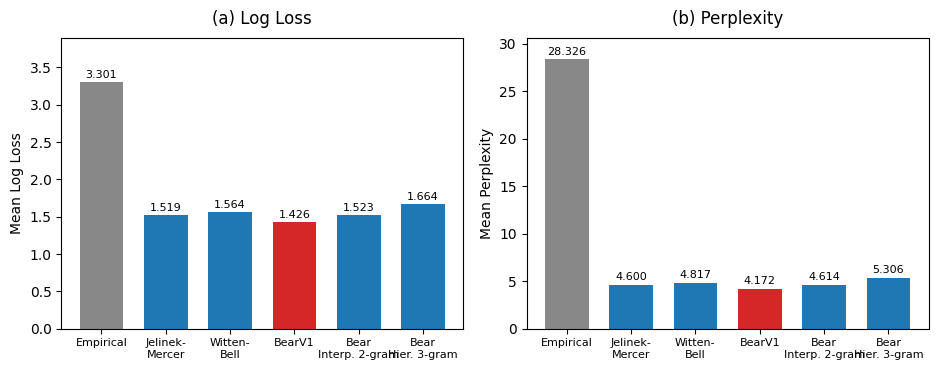

Saved: extended_corpus.pdf, extended_corpus.png


In [ ]:

import matplotlib.pyplot as plt
import numpy as np

models = ["Empirical", "Jelinek-\nMercer", "Witten-\nBell",
          "BearV1", "Bear\nInterp. 2-gram", "Bear\nHier. 3-gram"]

mean_ll = np.array([3.3009, 1.5190, 1.5639, 1.4257, 1.5234, 1.6640])
mean_ppl = np.array([28.3257, 4.6000, 4.8169, 4.1724, 4.6144, 5.3060])

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
x = np.arange(len(models))
colors = ['#888888', '#1f77b4', '#1f77b4', '#d62728', '#1f77b4', '#1f77b4']

# (a) Log Loss
ax = axes[0]
ax.bar(x, mean_ll, width=0.68, color=colors)
ax.set_title("(a) Log Loss", pad=10)
ax.set_ylabel("Mean Log Loss")
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=8)
ax.set_ylim(0, max(mean_ll) * 1.18)
for i, v in enumerate(mean_ll):
    ax.text(i, mean_ll[i] + 0.03, f"{v:.3f}",
            ha="center", va="bottom", fontsize=8)

# (b) Perplexity
ax = axes[1]
ax.bar(x, mean_ppl, width=0.68, color=colors)
ax.set_title("(b) Perplexity", pad=10)
ax.set_ylabel("Mean Perplexity")
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=8)
ax.set_ylim(0, max(mean_ppl) * 1.08)
for i, v in enumerate(mean_ppl):
    ax.text(i, mean_ppl[i] + 0.3, f"{v:.3f}",
            ha="center", va="bottom", fontsize=8)

fig.tight_layout()
fig.savefig("/content/extended_corpus.pdf", bbox_inches="tight")
fig.savefig("/content/extended_corpus.png", bbox_inches="tight")
plt.show()
print("Saved: extended_corpus.pdf, extended_corpus.png")